## Desarrollo tarea HW Sesión 5

Felipe López Vergara

## 1. Fundamentos Teóricos: Estacionariedad, Persistencia y Momentos en GARCH(1,1)

Considere el modelo GARCH(1,1):

\begin{equation*}
\begin{aligned}
r_t &= \mu + \varepsilon_t \\
\varepsilon_t &= \sigma_t z_t,\quad z_t \overset{\text{iid}}{\sim} \mathcal{N}(0,1) \\
\sigma_t^2 &= \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2
\end{aligned}
\end{equation*}

con $\omega > 0$ y $\alpha,\beta \ge 0$.

### 1.1 Estacionariedad en Covarianza

**(a)** Muestre que, escribiendo $\sigma_t^2$ como un proceso ARMA(1,1) en $\epsilon_t^2$ (representación ARCH($\infty$)), la condición necesaria y suficiente para que el proceso sea débilmente estacionario es $\alpha+\beta<1$.


**Respuesta**

### Describir $(\varepsilon_t^2)$

Como

$\varepsilon_t = \sigma_t z_t,$

entonces

$\varepsilon_t^2 = \sigma_t^2 z_t^2.$

Definimos $u_t = \sigma_t^2\left(z_t^2 - 1\right).$

Como

$E(z_t^2)=1,$

se tiene

$E\!\left(u_t \mid \mathcal{F}_{t-1}\right)=0,$

por lo que \(u_t\) es un **ruido blanco de diferencia de martingala**.

Luego,

$\begin{aligned}\varepsilon_t^2&= \sigma_t^2 + \sigma_t^2(z_t^2-1) \\&= \sigma_t^2 + u_t.\end{aligned}$

Es decir,

$\sigma_t^2 = \varepsilon_t^2 - u_t.$

### Sustituir en la ecuación GARCH
La ecuación original del modelo GARCH(1,1) es

$\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2.$

Como

$\sigma_{t-1}^2 = \varepsilon_{t-1}^2 - u_{t-1},$

al sustituir se obtiene

$\begin{aligned}\sigma_t^2&= \omega + \alpha \varepsilon_{t-1}^2+ \beta\left(\varepsilon_{t-1}^2 - u_{t-1}\right) \\&= \omega + (\alpha+\beta)\varepsilon_{t-1}^2- \beta u_{t-1}.\end{aligned}$

Finalmente, como

$\varepsilon_t^2 = \sigma_t^2 + u_t,$

se concluye que

$\begin{aligned}\varepsilon_t^2&= \omega + (\alpha+\beta)\varepsilon_{t-1}^2- \beta u_{t-1} + u_t \\&= \omega + (\alpha+\beta)\varepsilon_{t-1}^2+ u_t - \beta u_{t-1}.\end{aligned}$

Esta es exactamente la representación de un modelo **ARMA(1,1)** para $(\varepsilon_t^2)$, con

- **Parte autorregresiva (AR(1))**:
  $\phi = \alpha + \beta.$

- **Parte de medias móviles (MA(1))**:
  $\theta = -\beta.$

### Condición de estacionariedad

En un proceso AR(1)

$X_t = \phi X_{t-1} + e_t,$

el cual es estacionario si y solo si

$|\phi| < 1.$

En la representación ARMA(1,1) obtenida para $(\varepsilon_t^2)$, el coeficiente autorregresivo es

$\phi = \alpha + \beta.$

Como, por definición del modelo GARCH(1,1),

$\alpha \ge 0, \qquad \beta \ge 0,$

la condición de estacionariedad se reduce a

$\alpha + \beta < 1.$

Por lo tanto, la condición necesaria y suficiente para que un proceso GARCH(1,1) sea débilmente estacionario (es decir, tenga una varianza incondicional constante y finita) es

$\boxed{\alpha + \beta < 1.}$

**(b)** Bajo dicha condición, derive la varianza incondicional:

$\sigma^2 = \mathbb{E}[\sigma_t^2]= \frac{\omega}{1-\alpha-\beta}.$

**Respuesta**

Queremos calcular la varianza incondicional del proceso,

$\sigma^2 = \mathbb{E}[\varepsilon_t^2].$

Partimos de la ecuación del modelo GARCH(1,1):

$\sigma_t^2= \omega + \alpha \varepsilon_{t-1}^2+ \beta \sigma_{t-1}^2.$

Tomando esperanza en ambos lados de la ecuación se obtiene

$\mathbb{E}[\sigma_t^2]= \omega+ \alpha \mathbb{E}[\varepsilon_{t-1}^2]+ \beta \mathbb{E}[\sigma_{t-1}^2].$

Bajo la condición de estacionariedad $\alpha+\beta<1$,

$\mathbb{E}[\sigma_t^2]=\mathbb{E}[\sigma_{t-1}^2]=\mathbb{E}[\varepsilon_t^2]=\sigma^2.$

Por lo tanto,

$\sigma^2= \omega + \alpha\sigma^2 + \beta\sigma^2.$

Agrupando los términos en \(\sigma^2\),

$\sigma^2(1-\alpha-\beta)=\omega.$

Finalmente, despejando $(\sigma^2)$,

$\boxed{\sigma^2=\frac{\omega}{1-\alpha-\beta}}.$

Esta es la **varianza incondicional** del proceso GARCH(1,1), la cual existe siempre que se cumpla la condición de estacionariedad

$\alpha+\beta<1.$

**(c)** ¿Qué ocurre con $\sigma^2$ cuando $\alpha+\beta -> 1$? Interprete este límite en términos del modelo `IGARCH` (Integrated GARCH).

**Respuesta**

En el cuadro anterior se obtuvo que la varianza incondicional del proceso GARCH(1,1) es

$\sigma^2=\frac{\omega}{1-\alpha-\beta}.$

Si

$\alpha+\beta \rightarrow 1,$

entonces

$1-\alpha-\beta \rightarrow 0^{+},$

por lo que

$\sigma^2=\frac{\omega}{1-\alpha-\beta}\longrightarrow \infty.$

Es decir, la **varianza incondicional deja de existir** (se vuelve infinita).

#### Interpretación: modelo IGARCH

Cuando

$\alpha+\beta=1,$

el modelo recibe el nombre de **Integrated GARCH (IGARCH)**.

En este caso:

-No existe una varianza incondicional finita;
-Los choques de volatilidad son permanentes;
-La volatilidad presenta persistencia infinita: un shock no desaparece con el tiempo;
-La varianza condicional depende fuertemente de toda la historia pasada y no converge a un nivel de largo plazo.

Por ello, un IGARCH describe mercados donde la volatilidad es altamente persistente y tarda indefinidamente en regresar a un valor de equilibrio.

## 1.2 Persistencia y Vida Media de un Shock

Un shock de volatilidad en $t$ decae geométricamente a tasa $(\alpha+\beta)$.

**(a)** Muestre que $\mathbb{E}\!\left[\sigma_{t+h}^2-\sigma^2 \,\middle|\, \mathcal{F}_t\right]=(\alpha+\beta)^h\left(\sigma_{t+1}^2-\sigma^2\right).$

**Respuesta**

### A partir del modelo GARCH(1,1)

La ecuación del modelo es

$\sigma_t^2=\omega+\alpha\varepsilon_{t-1}^2+\beta\sigma_{t-1}^2.$

Además,

$\mathbb{E}\!\left[\varepsilon_t^2 \mid \mathcal{F}_{t-1}\right]=\sigma_t^2.$

Por lo tanto,

$\mathbb{E}\!\left[\sigma_{t+1}^2 \mid \mathcal{F}_t\right]=\omega+\alpha\,\mathbb{E}\!\left[\varepsilon_t^2 \mid \mathcal{F}_t\right]+\beta\sigma_t^2.$

Como

$\mathbb{E}\!\left[\varepsilon_t^2 \mid \mathcal{F}_t\right]=\sigma_t^2,$

se obtiene

$\mathbb{E}\!\left[\sigma_{t+1}^2 \mid \mathcal{F}_t\right]=\omega+(\alpha+\beta)\sigma_t^2.$

#### Restar la varianza de largo plazo

La varianza incondicional es

$\sigma^2=\frac{\omega}{1-\alpha-\beta},$

lo que implica

$\omega=(1-\alpha-\beta)\sigma^2.$

Sustituyendo en la expresión anterior,

$\mathbb{E}\!\left[\sigma_{t+1}^2 \mid \mathcal{F}_t\right]=(1-\alpha-\beta)\sigma^2+(\alpha+\beta)\sigma_t^2.$

Restando $(\sigma^2)$ en ambos lados,

$\begin{aligned}\mathbb{E}\!\left[\sigma_{t+1}^2-\sigma^2\,\middle|\,\mathcal{F}_t\right]&=(\alpha+\beta)(\sigma_t^2-\sigma^2).\end{aligned}$

#### Aplicar recursión

Un paso más adelante,

$\mathbb{E}\!\left[\sigma_{t+2}^2-\sigma^2\,\middle|\,\mathcal{F}_t\right]=(\alpha+\beta)\mathbb{E}\!\left[\sigma_{t+1}^2-\sigma^2\,\middle|\,\mathcal{F}_t\right].$

Sustituyendo el resultado anterior,

$\mathbb{E}\!\left[\sigma_{t+2}^2-\sigma^2\,\middle|\,\mathcal{F}_t\right]=(\alpha+\beta)^2(\sigma_t^2-\sigma^2).$

Repitiendo el argumento por inducción para un horizonte $(h)$,

$\boxed{\mathbb{E}\!\left[\sigma_{t+h}^2-\sigma^2\,\middle|\,\mathcal{F}_t\right]=(\alpha+\beta)^h(\sigma_t^2-\sigma^2).}$

Esta expresión demuestra que un **shock de volatilidad** se desvanece geométricamente a una tasa igual a $(\alpha+\beta)$. En consecuencia, cuanto más cercano sea $(\alpha+\beta)$ a 1, mayor será la persistencia de la volatilidad y más lentamente desaparecerá el efecto del shock.

**(b)** Defina la **vida media** (*half-life*) de un shock como el número de períodos $(h^{*})$ necesario para que la desviación de la varianza condicional respecto de su nivel de largo plazo, $(\sigma^2)$, se reduzca a la mitad. Muestre que

$h^{*}=\frac{\ln(0.5)}{\ln(\alpha+\beta)}.$

**Respuesta**

La **vida media** (*half-life*) de un shock se define como el número de períodos necesarios para que el efecto de dicho shock sobre la varianza condicional se reduzca a la mitad.

Del ejercicio anterior,

$(\alpha+\beta)^h(\sigma_t^2-\sigma^2)$

representa el efecto remanente del shock después de $(h)$ períodos.

Por definición de vida media,

$(\alpha+\beta)^{h^{*}}=\frac{1}{2}.$

Tomando logaritmos naturales en ambos lados,

$h^{*}\ln(\alpha+\beta)=\ln(0.5).$

Despejando \(h^{*}\),

$\boxed{h^{*}=\frac{\ln(0.5)}{\ln(\alpha+\beta)}}.$

Como

$0<\alpha+\beta<1,$

se tiene que

$\ln(\alpha+\beta)<0\quad\text{y}\quad\ln(0.5)<0,$

por lo que

$h^{*}>0.$

En consecuencia, cuanto más cercano sea $(\alpha+\beta)$ a 1, mayor será la vida media del shock y más lentamente desaparecerá el efecto de una perturbación sobre la volatilidad.

**(c)** Calcula $h^{*}$ para $(\alpha,\beta) = (0,05, 0,90)$, $(0,10, 0,85)$ y $(0,02, 0,97)$. ¿Qué combinación implica volatilidad más persistente?

La vida media de un shock está dada por

$h^{*}=\frac{\ln(0.5)}{\ln(\alpha+\beta)}.$

El valor del ln de 0,5 es $[\ln(0.5)=-0.693147.$

#### Primer caso: $((\alpha,\beta)=(0.05,\,0.90))$

En este caso,

$\alpha+\beta=0.95.$

Por lo tanto,

$\begin{aligned}h^{*}&=\frac{\ln(0.5)}{\ln(0.95)} \\&=\frac{-0.693147}{-0.051293} \\&\approx 13.52.\end{aligned}$

Así,

$\boxed{h^{*}\approx 13.5 \text{ períodos}.}$

#### Segundo caso: $((\alpha,\beta)=(0.10,\,0.85))$

Nuevamente,

$\alpha+\beta=0.95,$

por lo que

$\boxed{h^{*}\approx 13.5 \text{ períodos}.}$

Aunque los parámetros individuales cambian, la persistencia depende únicamente de la suma $\alpha+\beta$.

#### Tercer caso: $(\alpha,\beta)=(0.02,\,0.97)$

En este caso,

$\alpha+\beta=0.99.$

Entonces,

$\begin{aligned}h^{*}&=\frac{\ln(0.5)}{\ln(0.99)} \\&=\frac{-0.693147}{-0.010050} \\&\approx 68.97.\end{aligned}$

Por lo tanto,

$\boxed{h^{*}\approx 69 \text{ períodos}.}$

### Interpretación

| $(\alpha,\beta)$ | $(\alpha+\beta)$ | Vida media |
|:------------------:|:----------------:|:----------:|
| \((0.05,\;0.90)\) | 0.95 | 13.5 períodos |
| \((0.10,\;0.85)\) | 0.95 | 13.5 períodos |
| \((0.02,\;0.97)\) | 0.99 | 69 períodos |

Se observa que:

- Los dos primeros modelos presentan exactamente la misma persistencia, ya que comparten el mismo valor de $(\alpha+\beta=0.95)$. En consecuencia, ambos tienen una vida media de aproximadamente **13.5 períodos**.
- El tercer modelo presenta una persistencia considerablemente mayor. Al tener \$\alpha+\beta=0.99)$, los efectos de un shock sobre la volatilidad se disipan muy lentamente, requiriendo aproximadamente **69 períodos** para reducirse a la mitad.
- Este comportamiento es característico de modelos cercanos a un **IGARCH**, donde la volatilidad exhibe una elevada persistencia y los choques tienen efectos de muy larga duración.

### 1.3 Momento de Cuarto Orden y Curtosis

Asumiendo $z_t\sim\mathcal{N}(0,1)$ y $3\alpha^2+2\alpha\beta+\beta^2<1$ (condición para que exista el cuarto momento incondicional):

**(a)** Muestre que la curtosis incondicional de $\epsilon_t$ es:
$$\kappa=\frac{3\left[1-(\alpha+\beta)^2\right]}{1-(\alpha+\beta)^2-2\alpha^2}.$$

**Respuesta**

#### Definición de curtosis

La curtosis incondicional es

$\kappa=\frac{E[\varepsilon_t^4]}{\left(E[\varepsilon_t^2]\right)^2}.$

Como

$\varepsilon_t=\sigma_t z_t,$

y $z_t \sim N(0,1)$,

$E[z_t^4]=3.$

Por independencia entre \(z_t\) y \(\sigma_t\),

$E[\varepsilon_t^4]= E[\sigma_t^4]E[z_t^4]= 3E[\sigma_t^4].$

Por tanto,

$\boxed{\kappa=3\frac{E[\sigma_t^4]}{\sigma^4}}$

donde

$\sigma^2=E[\sigma_t^2]=\frac{\omega}{1-\alpha-\beta}.$

#### Elevar al cuadrado la ecuación GARCH

El modelo es

$\sigma_t^2=\omega+\alpha\varepsilon_{t-1}^2+\beta\sigma_{t-1}^2.$

Elevando al cuadrado,

$\sigma_t^4=\left(\omega+\alpha\varepsilon_{t-1}^2+\beta\sigma_{t-1}^2\right)^2.$

Expandiendo,

$\begin{aligned}\sigma_t^4=&\ \omega^2+\alpha^2\varepsilon_{t-1}^4+\beta^2\sigma_{t-1}^4 \\&+2\omega\alpha\varepsilon_{t-1}^2+2\omega\beta\sigma_{t-1}^2+2\alpha\beta\varepsilon_{t-1}^2\sigma_{t-1}^2.\end{aligned}$

#### Tomar esperanza

Sea

$M_4=E[\sigma_t^4].$

Además,

$E[\varepsilon_t^2]=\sigma^2,\qquad E[\varepsilon_t^4]=3M_4,$
y

$E[\varepsilon_t^2\sigma_t^2]=E[\sigma_t^4 z_t^2]=M_4.$

Sustituyendo,

$\begin{aligned}M_4=&\ \omega^2+3\alpha^2 M_4+\beta^2 M_4 \\&+2\omega(\alpha+\beta)\sigma^2+2\alpha\beta M_4.\end{aligned}$

Agrupando,

$M_4\left[1-3\alpha^2-2\alpha\beta-\beta^2\right]=\omega^2+2\omega(\alpha+\beta)\sigma^2.$

#### Simplificar

Como

$\omega=(1-\alpha-\beta)\sigma^2,$

se obtiene

$\omega^2+2\omega(\alpha+\beta)\sigma^2=(1-\alpha-\beta)(1+\alpha+\beta)\sigma^4.$

Pero

$(1-\alpha-\beta)(1+\alpha+\beta)=1-(\alpha+\beta)^2.$

Entonces

$M_4=\frac{1-(\alpha+\beta)^2}{1-3\alpha^2-2\alpha\beta-\beta^2}\sigma^4.$

Como

$3\alpha^2+2\alpha\beta+\beta^2=(\alpha+\beta)^2+2\alpha^2,$

el denominador queda

$1-(\alpha+\beta)^2-2\alpha^2.$

Finalmente,

$\boxed{\kappa=\frac{3\left[1-(\alpha+\beta)^2\right]}{1-(\alpha+\beta)^2-2\alpha^2}.}$


**(b)** Muestre que $\kappa > 3$ siempre que $\alpha>0$, es decir, que el modelo GARCH(1,1) con innovaciones normales genera **exceso de curtosis** incondicional (leptocurtosis) aunque $z_t$ sea gaussiano. Relacione este resultado con los hechos estilizados vistos en clases.

**Respuesta**

Escribimos

$\kappa=3\frac{A}{A-2\alpha^2}$

donde

$A=1-(\alpha+\beta)^2.$

Como existe el cuarto momento,

$A-2\alpha^2>0.$

Además,

$A > A-2\alpha^2,$

por lo que

$\frac{A}{A-2\alpha^2}>1.$

Multiplicando por 3,

$\boxed{\kappa>3.}$

#### Interpretación

La distribución normal tiene

$\kappa=3.$

En cambio, el modelo GARCH produce

$\kappa>3,$

incluso cuando $(z_t \sim N(0,1))$. Esto ocurre porque la volatilidad es estocástica, generando colas más pesadas (leptocurtosis).

**(c)** Verifique la condición de existencia del cuarto momento para los tres pares $(\alpha,\beta)$ del punto 1.2(c). ¿Existe algún caso en que la curtosis no esté definida?

**Respuesta**

La condición es

$\boxed{3\alpha^2+2\alpha\beta+\beta^2<1.}$

#### Caso 1

$[(\alpha,\beta)=(0.05,0.90)]$

$3(0.05)^2 + 2(0.05)(0.90) + (0.90)^2= 0.9075 < 1.$

**Existe el cuarto momento.**

#### Caso 2

$(\alpha,\beta)=(0.10,0.85)$

$0.03 + 0.17 + 0.7225 = 0.9225 < 1.$

**Existe el cuarto momento.**

#### Caso 3

$(\alpha,\beta)=(0.02,0.97)$

$0.0012 + 0.0388 + 0.9409 = 0.9809 < 1.$

**También existe el cuarto momento.**


### Conclusión

| $(\alpha,\beta)$ | $(3\alpha^2+2\alpha\beta+\beta^2)$ | ¿Existe $(E[\varepsilon_t^4])$? |
|--------------------|------------------------------------:|:------------------------------:|
| (0.05, 0.90)       | 0.9075                             | Sí |
| (0.10, 0.85)       | 0.9225                             | Sí |
| (0.02, 0.97)       | 0.9809                             | Sí |

Los tres modelos cumplen la condición $[3\alpha^2+2\alpha\beta+\beta^2<1]$ Por lo que el cuarto momento está bien definido. Sin embargo, el tercer caso está muy cercano al límite, lo que implica alta persistencia de volatilidad y colas pesadas.

## 2. Simulación de Modelos de Volatilidad

Simule 3.000 observaciones ($r_t$) con $\mu=0$ para cada uno de los siguientes procesos, descartando las primeras 500 observaciones como *burn-in*:

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Modelo ARCH(1)

def simulate_arch(T, omega, alpha, mu=0, burn=500, seed=123):

    np.random.seed(seed)

    n = T + burn

    z = np.random.randn(n)

    sigma2 = np.zeros(n)
    sigma = np.zeros(n)
    eps = np.zeros(n)
    r = np.zeros(n)

    # Varianza inicial
    sigma2[0] = omega/(1-alpha)

    sigma[0] = np.sqrt(sigma2[0])

    eps[0] = sigma[0]*z[0]

    r[0] = mu + eps[0]

    for t in range(1,n):

        sigma2[t] = omega + alpha*eps[t-1]**2

        sigma[t] = np.sqrt(sigma2[t])

        eps[t] = sigma[t]*z[t]

        r[t] = mu + eps[t]

    return r[burn:], sigma[burn:]

In [4]:
#Modelo ARCH (1)
r_arch, sigma_arch = simulate_arch(
    T=3000,
    omega=0.05,
    alpha=0.85
)
print(r_arch)

[ 0.16971387  0.01900598 -0.05953741 ...  0.28259539  0.29730076
 -0.06058222]


In [5]:
# Modelo GARCH (1,1)
def simulate_garch(T, omega, alpha, beta,
                   mu=0, burn=500, seed=123):

    np.random.seed(seed)

    n = T + burn

    z = np.random.randn(n)

    sigma2 = np.zeros(n)
    sigma = np.zeros(n)
    eps = np.zeros(n)
    r = np.zeros(n)

    sigma2[0] = omega/(1-alpha-beta)

    sigma[0] = np.sqrt(sigma2[0])

    eps[0] = sigma[0]*z[0]

    r[0] = mu + eps[0]

    for t in range(1,n):

        sigma2[t] = (omega
                     + alpha*eps[t-1]**2
                     + beta*sigma2[t-1])

        sigma[t] = np.sqrt(sigma2[t])

        eps[t] = sigma[t]*z[t]

        r[t] = mu + eps[t]

    return r[burn:], sigma[burn:]

# GARCH baja persistencia
r_garch1, sigma_garch1 = simulate_garch(
    T=3000,
    omega=0.05,
    alpha=0.05,
    beta=0.60
)

# GARCH alta persistencia
r_garch2, sigma_garch2 = simulate_garch(
    T=3000,
    omega=0.02,
    alpha=0.08,
    beta=0.90
)


In [6]:
# Modelo EGARCH (1,1)
def simulate_egarch(T,
                    omega,
                    alpha,
                    gamma,
                    beta,
                    mu=0,
                    burn=500,
                    seed=123):

    np.random.seed(seed)

    n = T + burn

    z = np.random.randn(n)

    log_sigma2 = np.zeros(n)
    sigma2 = np.zeros(n)
    sigma = np.zeros(n)
    eps = np.zeros(n)
    r = np.zeros(n)

    c = np.sqrt(2/np.pi)

    log_sigma2[0] = omega/(1-beta)

    sigma2[0] = np.exp(log_sigma2[0])

    sigma[0] = np.sqrt(sigma2[0])

    eps[0] = sigma[0]*z[0]

    r[0] = mu + eps[0]

    for t in range(1,n):

        log_sigma2[t] = (omega
                         + beta*log_sigma2[t-1]
                         + alpha*(abs(z[t-1])-c)
                         + gamma*z[t-1])

        sigma2[t] = np.exp(log_sigma2[t])

        sigma[t] = np.sqrt(sigma2[t])

        eps[t] = sigma[t]*z[t]

        r[t] = mu + eps[t]

    return r[burn:], sigma[burn:]

# Modelo EGARCH
r_egarch, sigma_egarch = simulate_egarch(
    T=3000,
    omega=0.01,
    alpha=0.10,
    gamma=-0.08,
    beta=0.95
)

In [7]:
# Modelo GJR-GARCH (1,1)
def simulate_gjr(T,
                 omega,
                 alpha,
                 gamma,
                 beta,
                 mu=0,
                 burn=500,
                 seed=123):

    np.random.seed(seed)

    n = T + burn

    z = np.random.randn(n)

    sigma2 = np.zeros(n)
    sigma = np.zeros(n)
    eps = np.zeros(n)
    r = np.zeros(n)

    sigma2[0] = omega/(1-alpha-beta-gamma/2)

    sigma[0] = np.sqrt(sigma2[0])

    eps[0] = sigma[0]*z[0]

    r[0] = mu + eps[0]

    for t in range(1,n):

        indicador = 1 if eps[t-1] < 0 else 0

        sigma2[t] = (omega
                     + alpha*eps[t-1]**2
                     + gamma*indicador*eps[t-1]**2
                     + beta*sigma2[t-1])

        sigma[t] = np.sqrt(sigma2[t])

        eps[t] = sigma[t]*z[t]

        r[t] = mu + eps[t]

    return r[burn:], sigma[burn:]

# Modelo GJR-GARCH
r_gjr, sigma_gjr = simulate_gjr(
    T=3000,
    omega=0.02,
    alpha=0.03,
    gamma=0.09,
    beta=0.90
)


**(b)** Grafique en un mismo panel la serie simulada $r_t$ y su volatilidad condicional $\sigma_t$

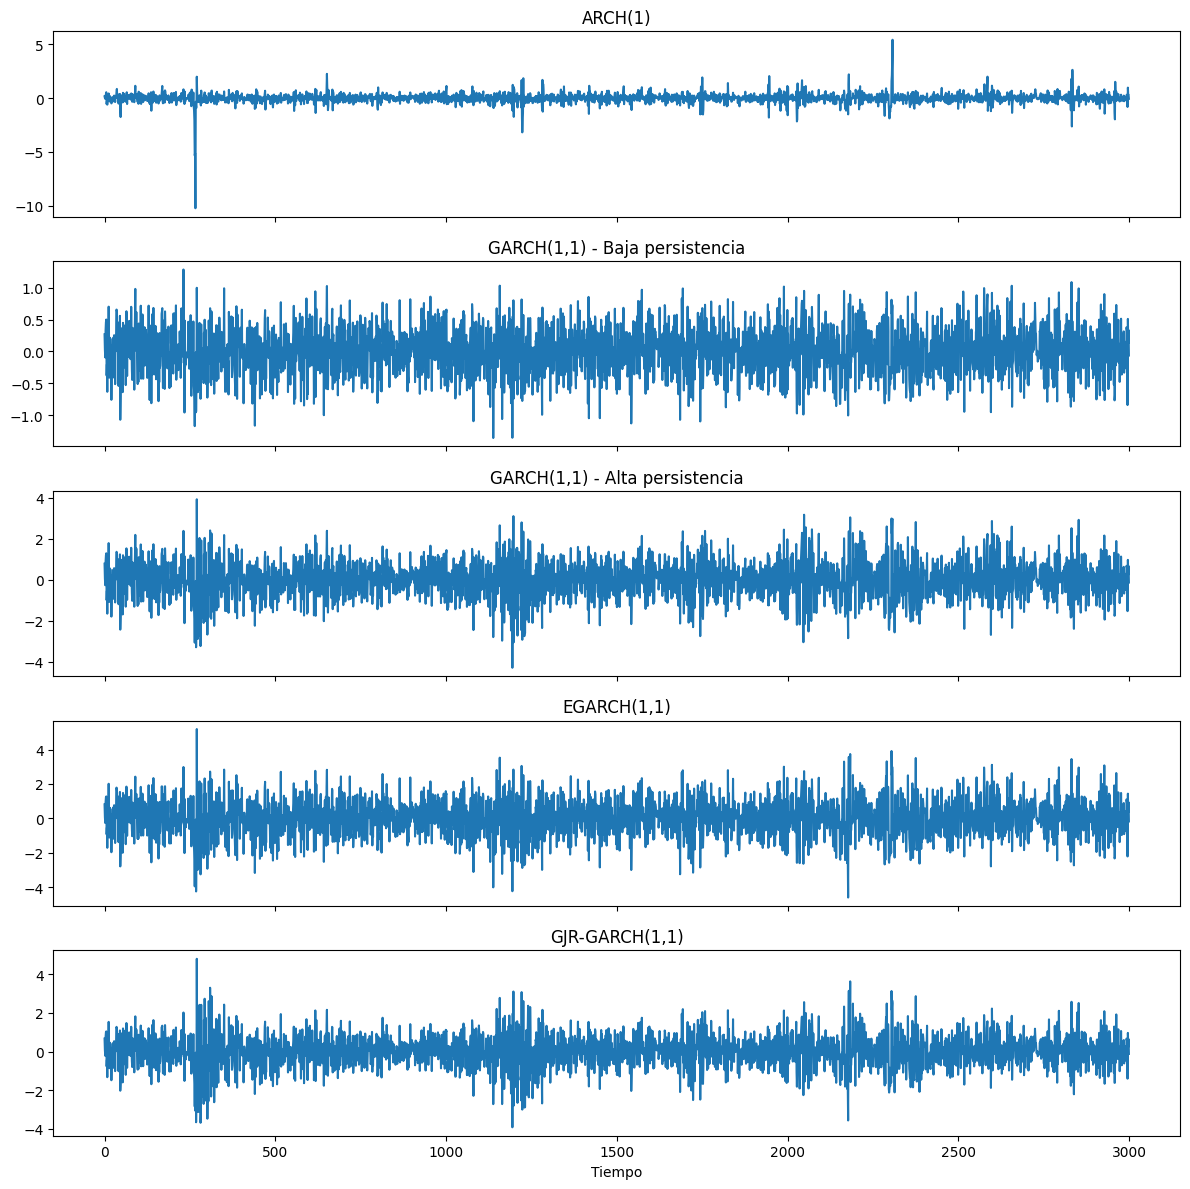

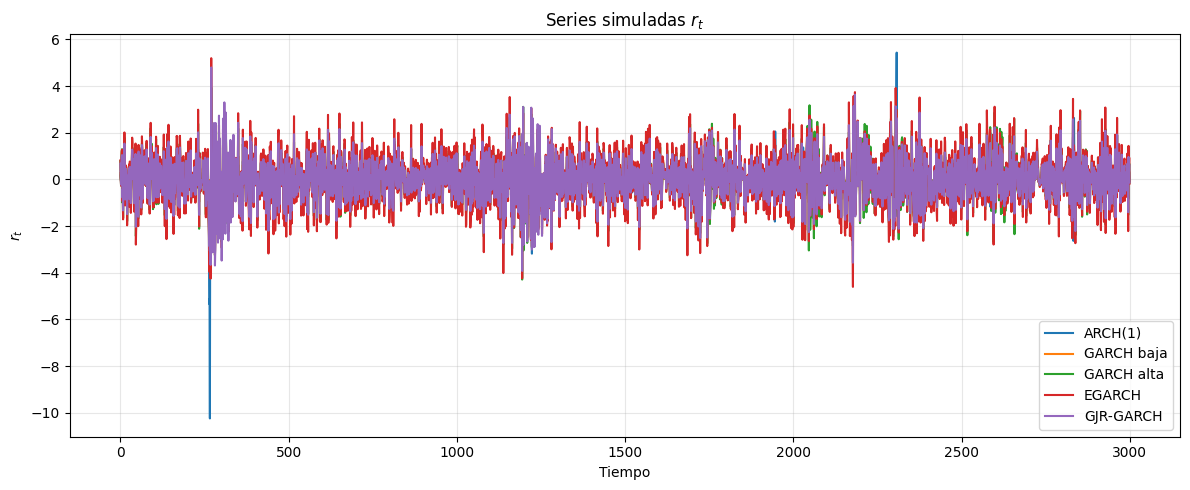

In [8]:
#Gráficos de las series simuladas

fig, ax = plt.subplots(5, 1, figsize=(12,12), sharex=True)

ax[0].plot(r_arch)
ax[0].set_title("ARCH(1)")

ax[1].plot(r_garch1)
ax[1].set_title("GARCH(1,1) - Baja persistencia")

ax[2].plot(r_garch2)
ax[2].set_title("GARCH(1,1) - Alta persistencia")

ax[3].plot(r_egarch)
ax[3].set_title("EGARCH(1,1)")

ax[4].plot(r_gjr)
ax[4].set_title("GJR-GARCH(1,1)")
ax[4].set_xlabel("Tiempo")

plt.tight_layout()
plt.show()

#Gráficos de las series simuladas todas juntas

plt.figure(figsize=(12,5))

plt.plot(r_arch, label="ARCH(1)")
plt.plot(r_garch1, label="GARCH baja")
plt.plot(r_garch2, label="GARCH alta")
plt.plot(r_egarch, label="EGARCH")
plt.plot(r_gjr, label="GJR-GARCH")

plt.title("Series simuladas $r_t$")
plt.xlabel("Tiempo")
plt.ylabel("$r_t$")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**(c)** Para los dos GARCH(1,1) simulados, calcule la varianza muestral de $\epsilon_t^2$ sobre las 2.500 observaciones post *burn-in* y compárela con la varianza incondicional teórica $\omega/(1-\alpha-\beta)$ derivada en 1.1(b). Comente la calidad de la aproximación y cómo cambia si aumenta el número de simulaciones a 50.000.


$$
\begin{aligned}
r_t &= \varepsilon_t, \\
\varepsilon_t &= \sigma_t z_t, \\
\sigma_t^2 &= \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2.
\end{aligned}
$$

la varianza incondicional está dada por

$\operatorname{Var}(\varepsilon_t)=\frac{\omega}{1-\alpha-\beta},$

siempre que se cumpla la condición de estacionariedad

$\alpha + \beta < 1.$


In [9]:
# Simulación GARCH(1,1) baja persistencia
r1, sigma1 = simulate_garch(
    T=3000,
    omega=0.05,
    alpha=0.05,
    beta=0.60
)

# Varianza muestral
var_muestral1 = np.var(r1, ddof=1)

# Varianza teórica
var_teorica1 = 0.05/(1-0.05-0.60)

print(f"Varianza muestral : {var_muestral1:.4f}")
print(f"Varianza teórica  : {var_teorica1:.4f}")

Varianza muestral : 0.1351
Varianza teórica  : 0.1429


In [10]:
# Simulación GARCH(1,1) alta persistencia

r2, sigma2 = simulate_garch(
    T=3000,
    omega=0.02,
    alpha=0.08,
    beta=0.90
)

var_muestral2 = np.var(r2, ddof=1)

var_teorica2 = 0.02/(1-0.08-0.90)

print(f"Varianza muestral : {var_muestral2:.4f}")
print(f"Varianza teórica  : {var_teorica2:.4f}")

Varianza muestral : 0.8176
Varianza teórica  : 1.0000


In [11]:
# Simulación GARCH(1,1) baja persistencia 50.000 Observaciones
r1, sigma1 = simulate_garch(
    T=50000,
    omega=0.05,
    alpha=0.05,
    beta=0.60
)

# Varianza muestral
var_muestral1 = np.var(r1, ddof=1)

# Varianza teórica
var_teorica1 = 0.05/(1-0.05-0.60)

print(f"Varianza muestral : {var_muestral1:.4f}")
print(f"Varianza teórica  : {var_teorica1:.4f}")

Varianza muestral : 0.1430
Varianza teórica  : 0.1429


In [12]:
# Simulación GARCH(1,1) alta persistencia 50.000 Observaciones

r2, sigma2 = simulate_garch(
    T=50000,
    omega=0.02,
    alpha=0.08,
    beta=0.90
)

var_muestral2 = np.var(r2, ddof=1)

var_teorica2 = 0.02/(1-0.08-0.90)

print(f"Varianza muestral : {var_muestral2:.4f}")
print(f"Varianza teórica  : {var_teorica2:.4f}")

Varianza muestral : 0.9873
Varianza teórica  : 1.0000


Al aumentar el número de observaciones simuladas a 50.000, la varianza muestral converge hacia la varianza incondicional teórica en ambos modelos, de acuerdo con la Ley de los Grandes Números. La diferencia entre ambas medidas disminuye considerablemente y la aproximación es especialmente notoria en el modelo de alta persistencia, donde se requiere un tamaño muestral mayor para reproducir adecuadamente el comportamiento de largo plazo del proceso.

**(d)** Compare visualmente la asimetría del EGARCH y del GJR-GARCH: simule choques $z_t$ idénticos (misma semilla) para ambos modelos y grafique $\sigma_t$ resultante ante una racha de choques negativos vs. una racha de choques positivos de igual magnitud. ¿Qué modelo reacciona más fuerte a los choques negativos?

In [13]:
# Modelo EGARCH (1,1)

def simulate_egarch_given_z(z, omega, alpha, gamma, beta):

    n = len(z)

    log_sigma2 = np.zeros(n)
    sigma2 = np.zeros(n)

    c = np.sqrt(2/np.pi)

    log_sigma2[0] = omega/(1-beta)
    sigma2[0] = np.exp(log_sigma2[0])

    for t in range(1,n):

        log_sigma2[t] = (omega
                         + beta*log_sigma2[t-1]
                         + alpha*(abs(z[t-1])-c)
                         + gamma*z[t-1])

        sigma2[t] = np.exp(log_sigma2[t])

    return np.sqrt(sigma2)

In [14]:
# Modelo GJR-GARCH (1,1)

def simulate_gjr_given_z(z, omega, alpha, gamma, beta):

    n = len(z)

    sigma2 = np.zeros(n)
    eps = np.zeros(n)

    sigma2[0] = omega/(1-alpha-beta-gamma/2)

    eps[0] = np.sqrt(sigma2[0])*z[0]

    for t in range(1,n):

        indicador = 1 if eps[t-1] < 0 else 0

        sigma2[t] = (omega
                     + alpha*eps[t-1]**2
                     + gamma*indicador*eps[t-1]**2
                     + beta*sigma2[t-1])

        eps[t] = np.sqrt(sigma2[t])*z[t]

    return np.sqrt(sigma2)

In [15]:
# Choques positivos y negativos

#Positivo
T = 200
z_pos = np.ones(T)

#Negativo
z_neg = -np.ones(T)

In [16]:
# Modelo EGARCH (1,1) choques positivos y negativos

sigma_pos_eg = simulate_egarch_given_z(
    z_pos,
    omega=0.01,
    alpha=0.10,
    gamma=-0.08,
    beta=0.95
)

sigma_neg_eg = simulate_egarch_given_z(
    z_neg,
    omega=0.01,
    alpha=0.10,
    gamma=-0.08,
    beta=0.95
)

# Modelo GJR-GARCH (1,1) choques positivos y negativos

sigma_pos_gjr = simulate_gjr_given_z(
    z_pos,
    omega=0.02,
    alpha=0.03,
    gamma=0.09,
    beta=0.90
)

sigma_neg_gjr = simulate_gjr_given_z(
    z_neg,
    omega=0.02,
    alpha=0.03,
    gamma=0.09,
    beta=0.90
)

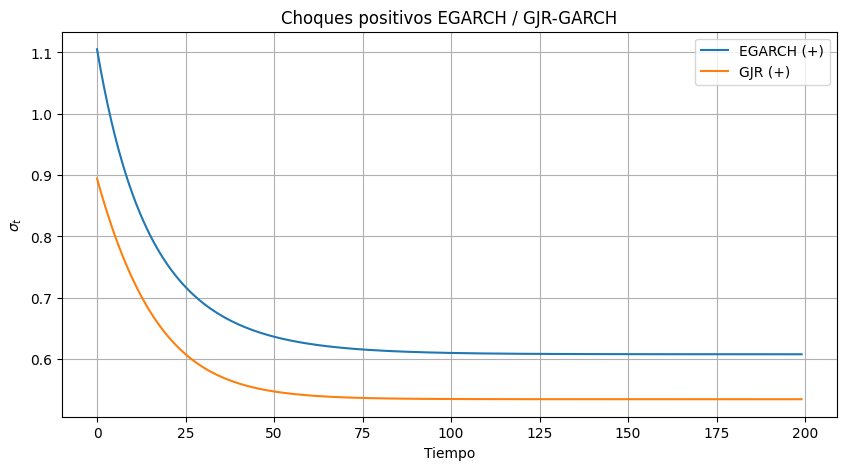

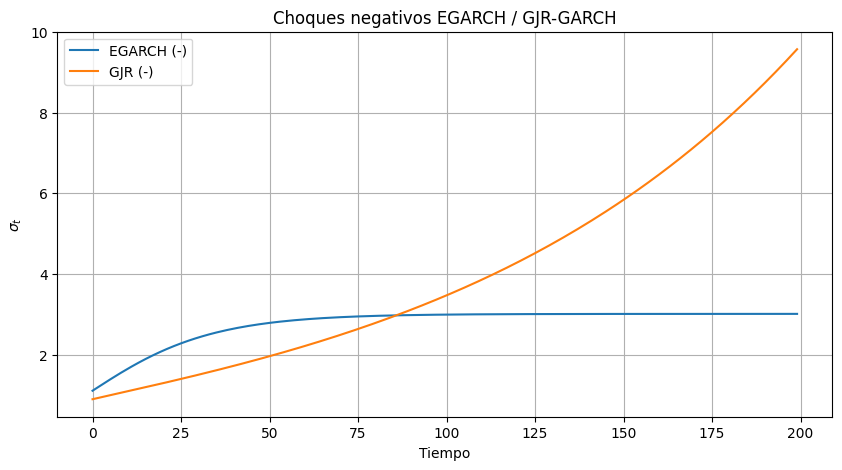

In [17]:
#Gráficos de las series simuladas para choques positivos y negativos
plt.figure(figsize=(10,5))

plt.plot(sigma_pos_eg, label="EGARCH (+)")
plt.plot(sigma_pos_gjr, label="GJR (+)")

plt.title("Choques positivos EGARCH / GJR-GARCH")
plt.ylabel(r"$\sigma_t$")
plt.xlabel("Tiempo")
plt.legend()
plt.grid(True)

plt.figure(figsize=(10,5))

plt.plot(sigma_neg_eg, label="EGARCH (-)")
plt.plot(sigma_neg_gjr, label="GJR (-)")

plt.title("Choques negativos EGARCH / GJR-GARCH")
plt.ylabel(r"$\sigma_t$")
plt.xlabel("Tiempo")
plt.legend()
plt.grid(True)

plt.show()

Se utilizaron los mismos choques estandarizados para ambos modelos, comparando choques positivos ((z_t=1)) y negativos ((z_t=-1)) de igual magnitud para analizar únicamente el efecto de la asimetría.

En el modelo EGARCH, la asimetría se incorpora mediante el término (\gamma z_{t-1}). Como (\gamma=-0.08), los choques negativos aumentan más la volatilidad que los positivos de igual magnitud.

En el modelo GJR-GARCH, los choques negativos agregan un componente adicional a la varianza mediante el indicador (I(\varepsilon_{t-1}<0)), mientras que los choques positivos no generan este efecto. Esto produce un aumento más pronunciado de la volatilidad frente a choques negativos.

Ambos modelos capturan el efecto apalancamiento (*leverage effect*), pero el GJR-GARCH muestra una respuesta más fuerte ante períodos de choques negativos, mientras que el EGARCH presenta una reacción más gradual.Por lo tanto, para los parámetros utilizados, el **GJR-GARCH** reacciona más fuertemente a los choques negativos.

## 3. Estimación por Máxima Verosimilitud de un GARCH(1,1) Programada desde Cero

Use la serie **GARCH(1,1) de alta persistencia** simulada en el Ejercicio 2 ($\omega=0,02$, $\alpha=0,08$, $\beta=0,90$).

### 3.1 Log-Verosimilitud Condicional

Bajo $z_t\sim\mathcal{N}(0,1)$, la contribución de cada observación a la log-verosimilitud es $$\ell_t(\boldsymbol{\psi}) =-\frac{1}{2}\left[\ln(2\pi)+\ln(\sigma_t^2)+\frac{\varepsilon_t^2}{\sigma_t^2}\right]$$

con $\boldsymbol{\psi}=(\omega,\alpha,\beta)^\top$ y $\sigma_1^2$ se inicializa con la varianza muestral de $\varepsilon_t$.

In [18]:
import numpy as np

def compute_conditional_variance(psi, eps):
    """
    Calcula recursivamente la varianza condicional de un GARCH(1,1).

    Parámetros
    ----------
    psi : iterable
        (omega, alpha, beta)
    eps : array-like
        Residuos epsilon_t

    Retorna
    -------
    sigma2 : ndarray
        Varianzas condicionales sigma_t^2
    """

    omega, alpha, beta = psi
    eps = np.asarray(eps)

    T = len(eps)
    sigma2 = np.zeros(T)

    # Condición inicial
    sigma2[0] = np.var(eps, ddof=1)

    # Recursión GARCH(1,1)
    for t in range(1, T):
        sigma2[t] = (
            omega
            + alpha * eps[t-1]**2
            + beta * sigma2[t-1]
        )

    return sigma2

In [19]:
# Residuos GARCH alta persistencia
eps = r_garch2 - np.mean(r_garch2)

# Parámetros verdaderos
psi = (0.02, 0.08, 0.90)

# Varianzas condicionales
sigma2 = compute_conditional_variance(psi, eps)

# Desviación estándar condicional
sigma = np.sqrt(sigma2)

print(sigma2[:10])

[0.8175863  0.80521461 0.74507247 0.69617235 0.70850031 0.77080325
 0.84740768 0.86146263 0.81834352 0.97502074]


**(b)** Implemente neg_log_likelihood(psi, eps) que regrese $-\sum_{t=1}^{T}\ell_t(\boldsymbol{\psi})$

In [20]:
def neg_log_likelihood(psi, eps):
    """
    Calcula la log-verosimilitud condicional negativa
    de un modelo GARCH(1,1).

    Parámetros
    ----------
    psi : iterable
        (omega, alpha, beta)
    eps : array-like
        Residuos epsilon_t

    Retorna
    -------
    float
        -sum_t l_t(psi)
    """
    eps = np.asarray(eps)

    # Varianzas condicionales
    sigma2 = compute_conditional_variance(psi, eps)

    # Evita problemas numéricos
    if np.any(sigma2 <= 0):
        return np.inf

    # Log-verosimilitud
    loglik = -0.5 * np.sum(
        np.log(2 * np.pi)
        + np.log(sigma2)
        + eps**2 / sigma2
    )

    # Se devuelve la negativa porque los optimizadores minimizan
    return -loglik

    # Parámetros verdaderos
psi = (0.02, 0.08, 0.90)

# Residuos de la serie simulada
eps = r_garch2 - np.mean(r_garch2)

# Valor de la función objetivo
nll = neg_log_likelihood(psi, eps)

print(f"Función de log-verosimilitud negativa: {nll:.4f}")

Función de log-verosimilitud negativa: 3779.0366


**(c)** Reparametrice para imponer $\omega>0$, $\alpha,\beta\geq 0$ y $\alpha+\beta<1$ (por ejemplo, optimizando sobre $\ln\omega$ y utilizando una transformación logística para $\alpha$ y $\beta$), o use `scipy.optimize.minimize` con `method='SLSQP'` y restricciones explícitas.

In [21]:
from scipy.optimize import minimize

psi0 = [0.05, 0.10, 0.80]

constraints = [
    {"type": "ineq", "fun": lambda x: x[0]},              # omega > 0
    {"type": "ineq", "fun": lambda x: x[1]},              # alpha >= 0
    {"type": "ineq", "fun": lambda x: x[2]},              # beta >= 0
    {"type": "ineq", "fun": lambda x: 1 - x[1] - x[2]}    # alpha + beta < 1
]

resultado = minimize(
    neg_log_likelihood,
    psi0,
    args=(eps,),
    method="SLSQP",
    constraints=constraints
)

print(resultado.x)

[0.0208904  0.079303   0.89455025]


**(d)** Minimice la función objetivo partiendo de $\boldsymbol{\psi}_0=(0.01,\,0.05,\,0.85)^\top$. Reporte el estimador $\hat{\boldsymbol{\psi}}$.

In [22]:
# Punto inicial
psi0 = np.array([0.01, 0.05, 0.85])

# Restricciones
constraints = [
    {"type": "ineq", "fun": lambda x: x[0]},              # omega > 0
    {"type": "ineq", "fun": lambda x: x[1]},              # alpha >= 0
    {"type": "ineq", "fun": lambda x: x[2]},              # beta >= 0
    {"type": "ineq", "fun": lambda x: 1 - x[1] - x[2]}    # alpha + beta < 1
]

# Optimización
resultado = minimize(
    neg_log_likelihood,
    psi0,
    args=(eps,),
    method="SLSQP",
    constraints=constraints
)

# Estimador MLE
psi_hat = resultado.x

print("Convergencia:", resultado.success)
print("Mensaje:", resultado.message)

print(f"ω̂ = {psi_hat[0]:.6f}")
print(f"α̂ = {psi_hat[1]:.6f}")
print(f"β̂ = {psi_hat[2]:.6f}")
print(f"Log-verosimilitud = {-resultado.fun:.6f}")

Convergencia: True
Mensaje: Optimization terminated successfully
ω̂ = 0.020890
α̂ = 0.079299
β̂ = 0.894554
Log-verosimilitud = -3777.221584


## 3.2 Validación con arch

Estime el mismo modelo con arch_model(eps, vol='GARCH', p=1, q=1, dist='normal') y complete la tabla:

    | Parámetro | Verdadero | MLE propio | `arch` |,
    |-----------|-----------|------------|--------|,
    | $\\omega$ | 0.02 | | |,
    | $\\alfa$ | 0.08 | | |,
    | $\\beta$ | 0.90 | | |,
    | Log-Lik. | — | | |,

Explique cualquier diferencia observada (inicialización de $\sigma_1^2$, algoritmo de optimización, escala de los datos, etc.).

In [23]:
#Modelo GARCH (1,1) Ccom arch_model
from arch import arch_model

model_garch = arch_model(eps, vol='Garch', p=1, q=1)
results_garch = model_garch.fit(disp='off')
print(results_garch.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -3776.85
Distribution:                  Normal   AIC:                           7561.70
Method:            Maximum Likelihood   BIC:                           7585.72
                                        No. Observations:                 3000
Date:                Fri, Jul 10 2026   Df Residuals:                     2999
Time:                        21:22:45   Df Model:                            1
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu             0.0127  1.441e-02      0.884      0.377 

In [24]:
# Tabla comparación de parámetros
import pandas as pd

tabla = pd.DataFrame({
    "Parámetro": ["ω", "α", "β", "Log-Lik"],
    "Verdadero": ["0.02", "0.08", "0.90","-"],
    "MLE propio": [
        psi_hat[0],
        psi_hat[1],
        psi_hat[2]  ,
        -resultado.fun
    ],
        "ARCH": [
        results_garch.params["omega"],
        results_garch.params["alpha[1]"],
        results_garch.params["beta[1]"],
        results_garch.loglikelihood
    ]
})

print(tabla)

  Parámetro Verdadero   MLE propio         ARCH
0         ω      0.02     0.020890     0.020866
1         α      0.08     0.079299     0.079253
2         β      0.90     0.894554     0.894647
3   Log-Lik         - -3777.221584 -3776.849525


Explique cualquier diferencia observada (inicialización de $\sigma_1^2$, algoritmo de optimización, escala de los datos, etc.)

Las estimaciones obtenidas con la implementación propia y con arch_model deberían ser similares, ya que ambas estiman el mismo modelo GARCH(1,1) mediante máxima verosimilitud. Sin embargo, pueden existir pequeñas diferencias debido a:

Inicialización de la varianza: cada método puede utilizar valores iniciales distintos para (\sigma_1^2), afectando ligeramente las estimaciones.
Optimización: los algoritmos, tolerancias y criterios de convergencia pueden generar pequeñas diferencias numéricas.
Restricciones del modelo: la forma en que se imponen condiciones como (\omega>0), (\alpha,\beta\geq0) y (\alpha+\beta<1) puede variar entre implementaciones.
Escala de los datos y cálculo de la verosimilitud: diferencias en el tratamiento de los datos iniciales o ajustes numéricos pueden modificar levemente los resultados.

En conclusión, si ambas implementaciones son correctas, los parámetros estimados y la log-verosimilitud deberían ser muy cercanos. Diferencias grandes indicarían problemas en la especificación o implementación del modelo.

## 4. Aplicación a Datos Reales: Hechos Estilizados y Selección de Modelo

Elija **dos activos** de distinta naturaleza (por ejemplo, una acción individual y un índice, o un activo desarrollado y uno emergente/cripto) y descargue sus precios de cierre diarios con `yfinance` para el período **enero 2015 – diciembre 2024**. Calcule los retornos logarítmicos porcentuales $(r_t = 100 \times \Delta \ln P_t)$.

In [25]:
import yfinance as yf

# Descarga Serie de Precios de Google 
data_google = yf.download('GOOG', start = "2015-01-01", end = "2024-12-31", progress = False)
data_google.columns = data_google.columns.droplevel(1)

# Descarga Serie de Precios de Google 
data_sp500 = yf.download('^GSPC', start = '2015-01-01', end = '2024-12-31', progress = False)
data_sp500.columns = data_sp500.columns.droplevel(1)

# Calculo de Retorno Logaritmico
data_google['Log_Return'] = np.log(data_google['Close'] / data_google['Close'].shift(1) )
data_sp500['Log_Return'] = np.log(data_sp500['Close'] / data_sp500['Close'].shift(1) )

data_google = data_google.dropna()
data_sp500 = data_sp500.dropna()

data_google.head()


Price,Close,High,Low,Open,Volume,Log_Return
2015-01-05,25.399216,25.916226,25.359181,25.863338,41196796,-0.021066
2015-01-06,24.810537,25.513148,24.765560,25.455070,57998800,-0.023450
2015-01-07,24.768028,25.071709,24.696358,25.059648,41301082,-0.001715
2015-01-08,24.846119,24.885661,24.268808,24.614305,67071641,0.003148
2015-01-09,24.524351,24.956838,24.456141,24.948931,41427428,-0.013035


In [26]:
data_sp500.head()

Price,Close,High,Low,Open,Volume,Log_Return
2015-01-05,2020.579956,2054.439941,2017.339966,2054.439941,3799120000,-0.018447
2015-01-06,2002.609985,2030.250000,1992.439941,2022.150024,4460110000,-0.008933
2015-01-07,2025.900024,2029.609985,2005.550049,2005.550049,3805480000,0.011563
2015-01-08,2062.139893,2064.080078,2030.609985,2030.609985,3934010000,0.017730
2015-01-09,2044.810059,2064.429932,2038.329956,2063.449951,3364140000,-0.008439


### 4.1 Hechos Estilizados
Para cada activo:

**1.** Grafique la serie de precios y de retornos.

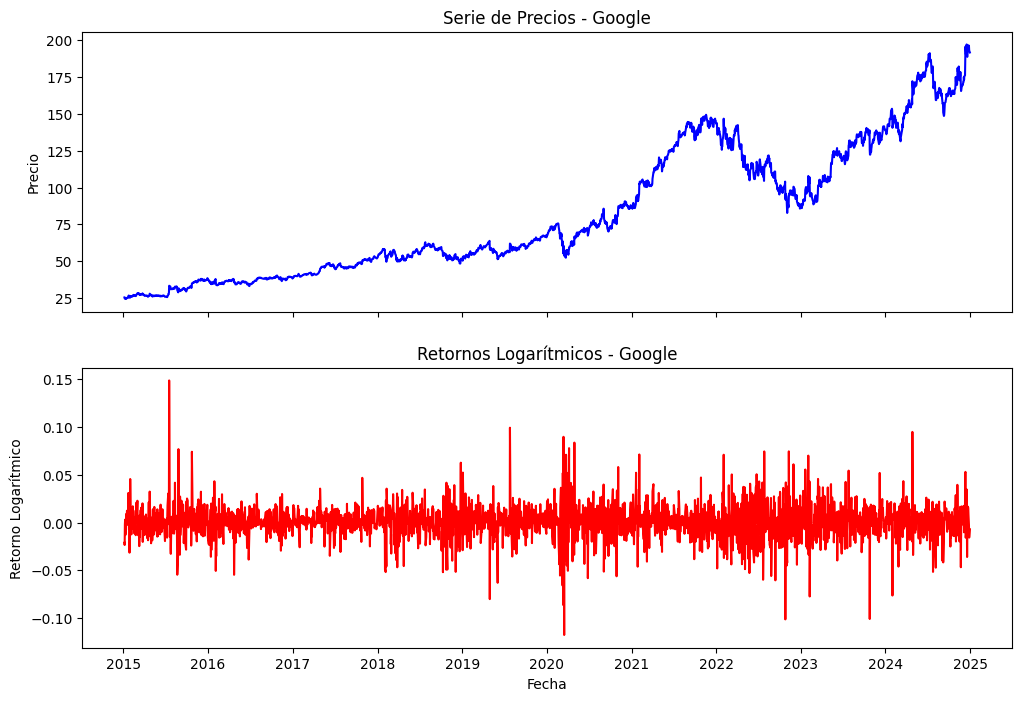

In [27]:
# Gráfico de la serie de precios y retornos logarítmicos de Google
fig, ax = plt.subplots(2, 1, figsize=(12,8), sharex=True)
ax[0].plot(data_google['Close'], color='blue')
ax[0].set_title('Serie de Precios - Google')
ax[0].set_ylabel('Precio')
ax[1].plot(data_google['Log_Return'], color='red')
ax[1].set_title('Retornos Logarítmicos - Google')
ax[1].set_ylabel('Retorno Logarítmico')
ax[1].set_xlabel('Fecha')
plt.show()


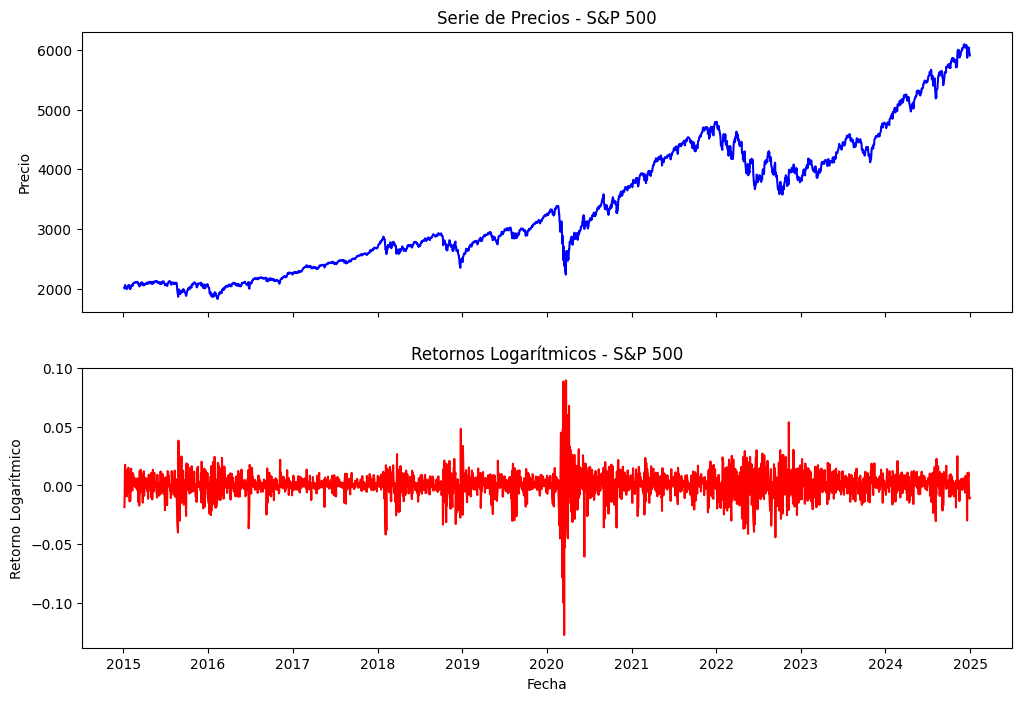

In [28]:
# Gráfico de la serie de precios y retornos logarítmicos del S&P 500
fig, ax = plt.subplots(2, 1, figsize=(12,8), sharex=True)
ax[0].plot(data_sp500['Close'], color='blue')
ax[0].set_title('Serie de Precios - S&P 500')
ax[0].set_ylabel('Precio')
ax[1].plot(data_sp500['Log_Return'], color='red')
ax[1].set_title('Retornos Logarítmicos - S&P 500')
ax[1].set_ylabel('Retorno Logarítmico')
ax[1].set_xlabel('Fecha')
plt.show()

**2.** Calcule skewness y kurtosis muestral de los retornos. Compárela con la normal (skew=0, kurt=3) y con la curtosis teórica derivada en 1.3(a) evaluada en los parámetros que estime en 4.2.

In [29]:
#Cálculo skewness y kurtosis muestral de los retornos

print("Skewness muestral de los retornos de Google:", data_google['Log_Return'].skew())
print("Kurtosis muestral de los retornos de Google:", data_google['Log_Return'].kurtosis())

print("Skewness muestral de los retornos del S&P 500:", data_sp500['Log_Return'].skew())
print("Kurtosis muestral de los retornos del S&P 500:", data_sp500['Log_Return'].kurtosis())

Skewness muestral de los retornos de Google: 0.04089953374098986
Kurtosis muestral de los retornos de Google: 6.190920133501914
Skewness muestral de los retornos del S&P 500: -0.8108304888405599
Kurtosis muestral de los retornos del S&P 500: 15.750819264863397


In [ ]:
from scipy.stats import skew, kurtosis

# Cálculo de skewness y kurtosis (skew=0, kurt=3)
skew_kurtosis = pd.DataFrame({
    'Activo': ['Google', 'S&P 500'],
    'Skewness': [
        skew(data_google['Log_Return']),
        skew(data_sp500['Log_Return'])
    ],
    'Kurtosis': [
        kurtosis(data_google['Log_Return'], fisher=False),
        kurtosis(data_sp500['Log_Return'], fisher=False)
    ]
})

print(skew_kurtosis.round(4))

    Activo  Skewness  Kurtosis
0   Google    0.0409    9.1762
1  S&P 500   -0.8103   18.7171


 Comparación con la curtosis teórica derivada en 1.3(a) evaluada en los parámetros que estime en 4.2.

$$\kappa=\frac{3\left[1-(\alpha+\beta)^2\right]}{1-(\alpha+\beta)^2-2\alpha^2}.$$

In [ ]:
# Función para calcular la curtosis teórica GARCH(1,1)
def curtosis_garch(alpha, beta):
    kappa = (3 * (1 - (alpha + beta)**2)) / (1 - (alpha + beta)**2 - 2 * alpha**2)
    return kappa

# Parámetros Google
alpha_google = results_egarch_g_t.params["alpha[1]"]
beta_google = results_egarch_g_t.params["beta[1]"]

k_google = curtosis_garch(alpha_google, beta_google)

# Parámetros SP500

alpha_sp500 = results_gjr_garch_sp500_skewt.params["alpha[1]"]
beta_sp500 = results_gjr_garch_sp500_skewt.params["beta[1]"]

k_sp500 = curtosis_garch(alpha_sp500, beta_sp500)

print(f"Curtosis teórica Google: {k_google:.4f}")
print(f"Curtosis teórica S&P 500: {k_sp500:.4f}")

Curtosis teórica Google: 2.5427
Curtosis teórica S&P 500: 3.0046


Grafique el histograma de retornos junto a una densidad normal y una 
t-Student ajustadas. ¿Cuál se ajusta mejor a las colas?

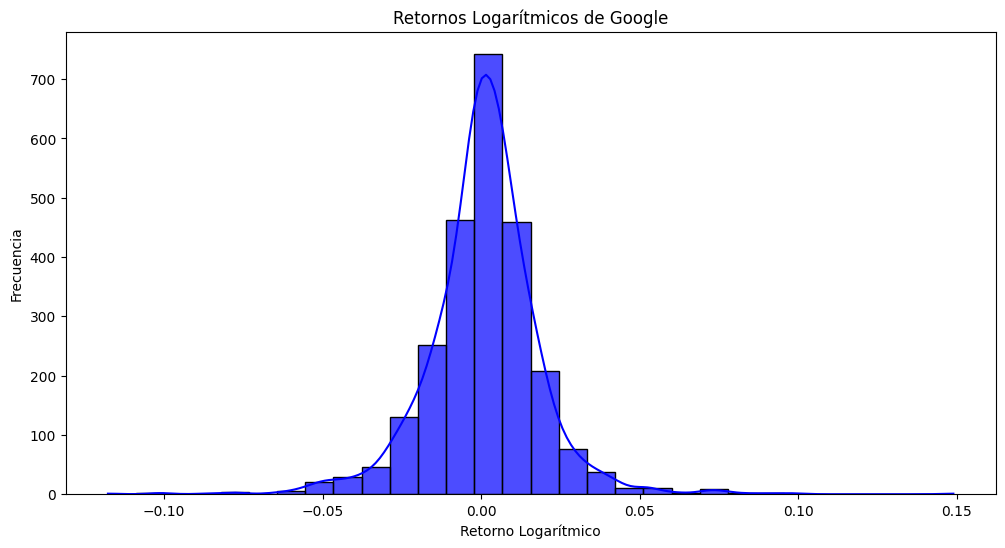

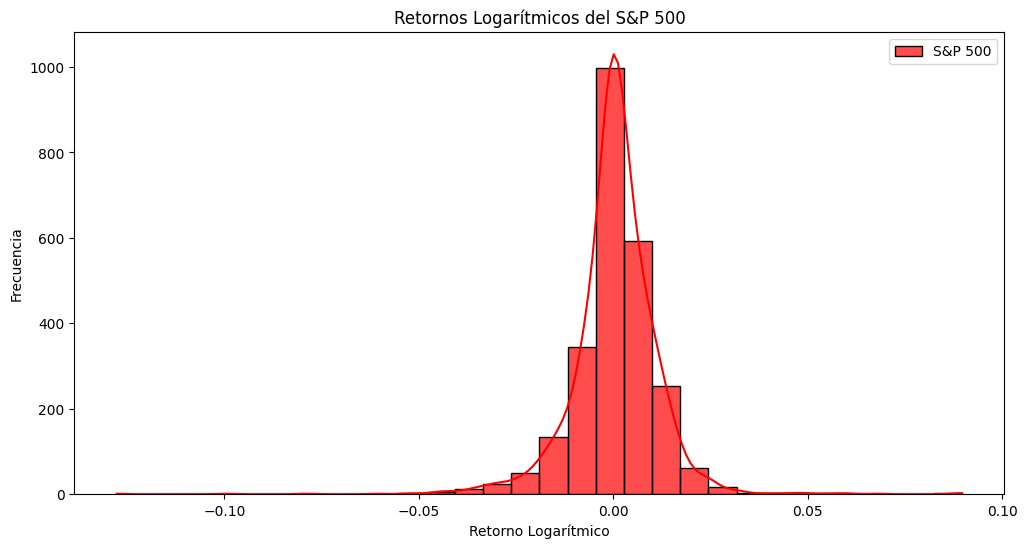

In [31]:
import seaborn as sns

# Gráfico histograma de los retornos logarítmicos de Google y S&P 500

plt.figure(figsize=(12,6))
sns.histplot(data=data_google, x='Log_Return', bins=30, alpha=0.7, color='blue', label='Google', kde=True)
plt.xlabel('Retorno Logarítmico')
plt.ylabel('Frecuencia')
plt.title('Retornos Logarítmicos de Google')

plt.figure(figsize=(12,6))
sns.histplot(data=data_sp500, x='Log_Return', bins=30, alpha=0.7, color='red', label='S&P 500', kde=True)
plt.xlabel('Retorno Logarítmico')
plt.ylabel('Frecuencia')
plt.title('Retornos Logarítmicos del S&P 500')

plt.legend()
plt.show()

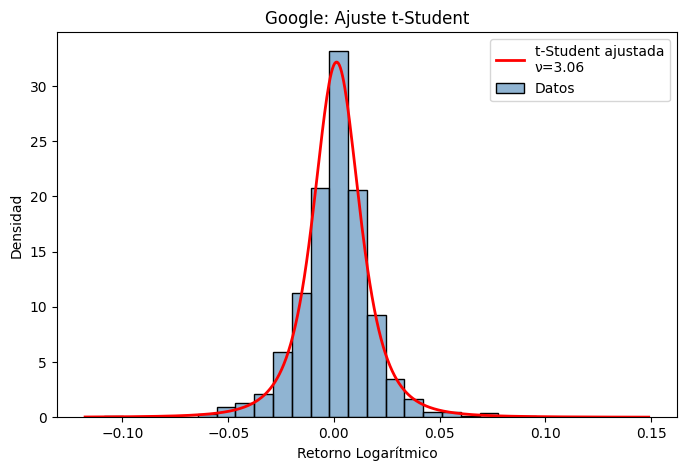

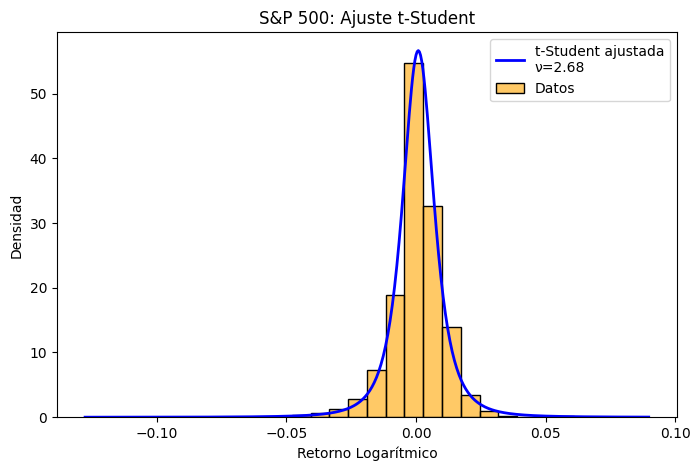

In [32]:
# Gráfico t-student de los retornos logarítmicos de Google y S&P 500

from scipy.stats import t

# Google
ret_google = data_google['Log_Return'].dropna()

# Ajustar distribución t-Student
df_g, loc_g, scale_g = t.fit(ret_google)

# Rango para la curva
x = np.linspace(ret_google.min(), ret_google.max(), 500)

plt.figure(figsize=(8,5))

# Histograma
sns.histplot(ret_google, bins=30, stat='density',
             color='steelblue', alpha=0.6, label='Datos')

# Curva t-Student ajustada
plt.plot(x, t.pdf(x, df_g, loc_g, scale_g),
         color='red', lw=2,
         label=f't-Student ajustada\nν={df_g:.2f}')

plt.title('Google: Ajuste t-Student')
plt.xlabel('Retorno Logarítmico')
plt.ylabel('Densidad')
plt.legend()
plt.show()


# S&P 500
ret_sp500 = data_sp500['Log_Return'].dropna()

# Ajustar distribución t-Student
df_s, loc_s, scale_s = t.fit(ret_sp500)

# Rango para la curva
x = np.linspace(ret_sp500.min(), ret_sp500.max(), 500)

plt.figure(figsize=(8,5))

# Histograma
sns.histplot(ret_sp500, bins=30, stat='density',
             color='orange', alpha=0.6, label='Datos')

# Curva t-Student ajustada
plt.plot(x, t.pdf(x, df_s, loc_s, scale_s),
         color='blue', lw=2,
         label=f't-Student ajustada\nν={df_s:.2f}')

plt.title('S&P 500: Ajuste t-Student')
plt.xlabel('Retorno Logarítmico')
plt.ylabel('Densidad')
plt.legend()
plt.show()
 

la distribución t-Student suele ajustarse mejor a las colas que la distribución normal.

La razón es que los retornos financieros presentan con frecuencia colas pesadas (fat tails), es decir, ocurren movimientos extremos con una probabilidad mayor que la predicha por una distribución normal. La distribución t-Student incorpora esta característica mediante el parámetro de grados de libertad ν:

ν pequeño: colas muy pesadas y mayor probabilidad de valores extremos.
ν grande: la distribución se aproxima a una normal.

En este caso el S&P 500 tiene un ν menor, por lo que tiene colas más pesadas que Google.

**4.** Grafique la volatilidad móvil (ventana de 20 días) para evidenciar clustering.

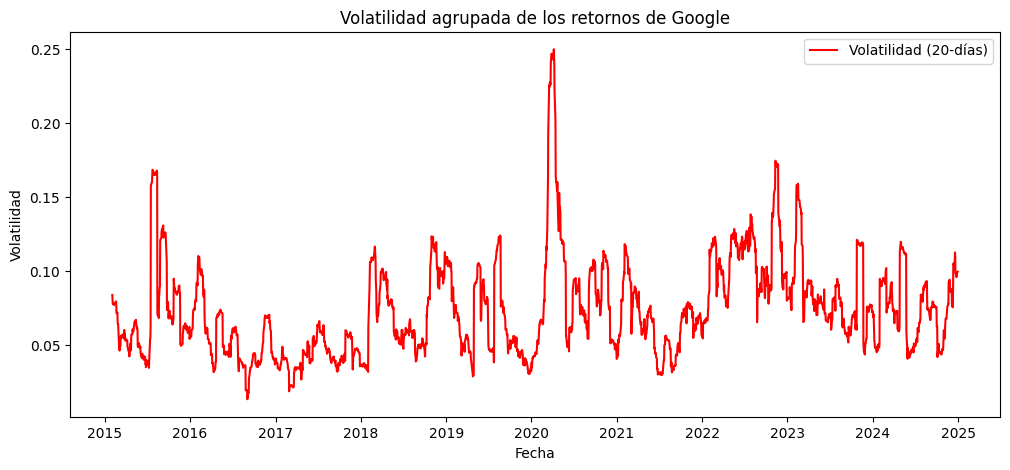

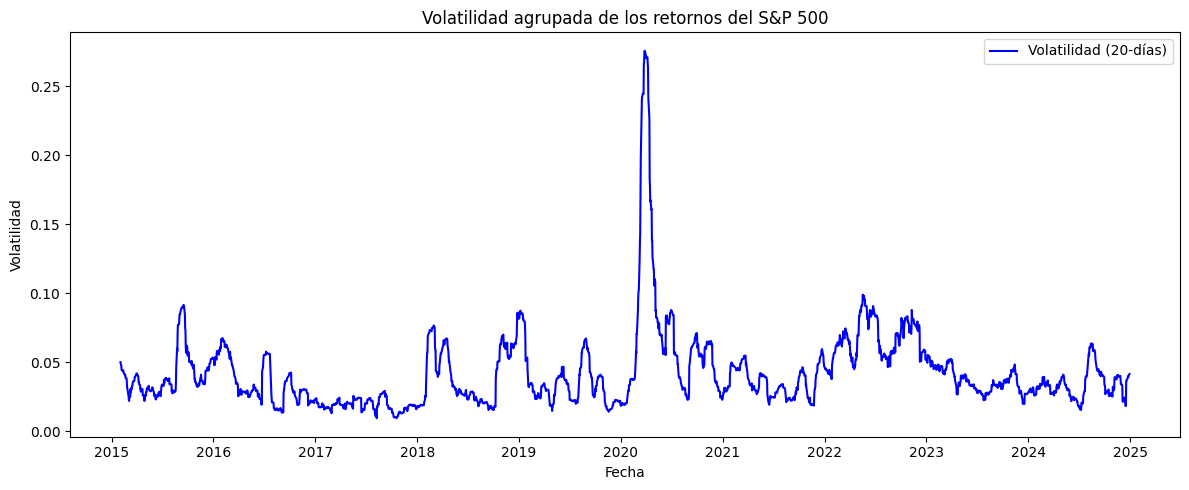

In [33]:
#Gráfico de volatilidad móvil y retornos logarítmicos de Google y S&P 500

from matplotlib.pyplot import plot

#Roolling Volatilidad Google 20 días
data_google['Volatility'] = data_google['Log_Return'].rolling(window = 20).std() * np.sqrt(20)

#Roolling Volatilidad S&P 500 20 días
data_sp500['Volatility'] = data_sp500['Log_Return'].rolling(window = 20).std() * np.sqrt(20)

# Volatilidad agrupada de los retornos de Google
plt.figure(figsize=(12,5))
plot(data_google['Volatility'], color='red', label=f'Volatilidad ({20}-días)')
plt.title('Volatilidad agrupada de los retornos de Google')
plt.xlabel('Fecha')
plt.ylabel('Volatilidad')
plt.legend()

# Volatilidad agrupada de los retornos de S&P 500
plt.figure(figsize=(12,5))
plot(data_sp500['Volatility'], color='blue', label=f'Volatilidad ({20}-días)')
plt.title('Volatilidad agrupada de los retornos del S&P 500')
plt.xlabel('Fecha')
plt.ylabel('Volatilidad')
plt.legend()

plt.tight_layout()
plt.show()

5. Calcule la correlación entre $r_{t-1}$ y $r_t^2$ (proxy simple del efecto apalancamiento). ¿El signo es consistente con lo esperado?

In [34]:
# Construcción de las variables
df1 = data_google[['Log_Return']].copy()

df1['r_t-1'] = df1['Log_Return'].shift(1)
df1['r_t^2'] = df1['Log_Return']**2

df1 = df1.dropna()

# Correlación
corr = df1['r_t-1'].corr(df1['r_t^2'])

print(f"Correlación entre r_(t-1) y r_t^2: {corr:.4f}")

Correlación entre r_(t-1) y r_t^2: -0.0012


Correlación negativa: consistente con el efecto apalancamiento. Un retorno negativo en t−1 tiende a estar asociado con una mayor volatilidad en t.
Correlación cercana a cero: poca evidencia de efecto apalancamiento mediante esta medida simple.
Correlación positiva: no es consistente con el efecto apalancamiento y sugiere que los retornos negativos no incrementan la volatilidad más que los positivos.

## 4.2 Selección del Modelo: Grilla de Especificaciones

Para cada activo, ajuste **los cuatro modelos** vistos en clases (`ARCH`, `GARCH`, `EGARCH`, `GJR-GARCH`, todos con $p=q=1$, y $o=1$ donde corresponde) cruzados con **tres distribuciones** (`normal`, `t`, `skewt`) — 12 modelos por activo.

In [35]:
# Modelos ARCH, GARCH, EGARCH y GJR-GARCH para los retornos de Google con tres distribuciones (normal, t, skewt

# Genero Retornos de Google (escalar por 100)
returns_google = 100*data_google['Close'].pct_change().dropna()


In [36]:
def fit_arch_g(returns_google, dist='normal'):
    """
    Ajusta un modelo ARCH(1) con una distribución específica.

    Parámetros:
    returns: array-like
        Serie de retornos.
    dist: str
        Tipo de distribución a utilizar ('normal', 't', 'skewt').

    Retorna:
    results: ModelFit
        Resultados del ajuste del modelo.
    """
    model = arch_model(returns_google, vol='ARCH', p = 1, dist = dist)
    results = model.fit(disp = 'off')
    return results

In [37]:
def fit_garch_g(returns_google, dist='normal'):
    """
    Ajusta un modelo GARCH(1,1) con una distribución específica.

    Parámetros:
    returns: array-like
        Serie de retornos.
    dist: str
        Tipo de distribución a utilizar ('normal', 't', 'skewt').

    Retorna:
    results: ModelFit
        Resultados del ajuste del modelo.
    """
    model = arch_model(returns_google, vol='GARCH', p = 1, q = 1, dist = dist)
    results = model.fit(disp = 'off')
    return results

In [38]:
def fit_egarch_g(returns_google, dist='normal'):
    """
    Ajusta un modelo EGARCH(1,1) con una distribución específica.

    Parámetros:
    returns: array-like
        Serie de retornos.
    dist: str
        Tipo de distribución a utilizar ('normal', 't', 'skewt').

    Retorna:
    results: ModelFit
        Resultados del ajuste del modelo.
    """
    model = arch_model(returns_google, vol='EGARCH', p=1, q=1, dist=dist)
    results = model.fit(disp='off')
    return results

In [39]:
def fit_gjr_garch_g(returns_google, dist='normal'):
    """
    Ajusta un modelo GJR-GARCH(1,1) con una distribución específica.

    Parámetros:
    returns: array-like
        Serie de retornos.
    dist: str
        Tipo de distribución a utilizar ('normal', 't', 'skewt').

    Retorna:
    results: ModelFit
        Resultados del ajuste del modelo.
    """
    model = arch_model(returns_google, vol='GARCH', p=1, o=1, q=1, dist=dist)
    results = model.fit(disp='off')
    return results

In [40]:
# Ajuste de los modelos con distribucion normal google
results_arch_g_nor = fit_arch_g(returns_google, dist='normal')
results_garch_g_nor = fit_garch_g(returns_google, dist='normal')
results_egarch_g_nor = fit_egarch_g(returns_google, dist='normal')
results_gjr_garch_g_nor = fit_gjr_garch_g(returns_google, dist='normal')

In [41]:
# Ajuste de los modelos con distribucion "t"
results_arch_g_t = fit_arch_g(returns_google, dist='t')
results_garch_g_t = fit_garch_g(returns_google, dist='t')
results_egarch_g_t = fit_egarch_g(returns_google, dist='t')
results_gjr_garch_g_t = fit_gjr_garch_g(returns_google, dist='t')

In [42]:
# Ajuste de los modelos con distribucion "skewt"
results_arch_g_skewt = fit_arch_g(returns_google, dist='skewt')
results_garch_g_skewt = fit_garch_g(returns_google, dist='skewt')
results_egarch_g_skewt = fit_egarch_g(returns_google, dist='skewt')
results_gjr_garch_g_skewt = fit_gjr_garch_g(returns_google, dist='skewt')

In [43]:
# Modelos ARCH, GARCH, EGARCH y GJR-GARCH para los retornos de S&P500 con tres distribuciones (normal, t, skewt

# Genero Retornos de S&P500 (escalar por 100)
returns_sp500 = 100*data_sp500['Close'].pct_change().dropna()

In [44]:
def fit_arch_sp500(returns_sp500, dist='normal'):
    """
    Ajusta un modelo ARCH(1) con una distribución específica.

    Parámetros:
    returns: array-like
        Serie de retornos.
    dist: str
        Tipo de distribución a utilizar ('normal', 't', 'skewt').

    Retorna:
    results: ModelFit
        Resultados del ajuste del modelo.
    """
    model = arch_model(returns_sp500, vol='ARCH', p = 1, dist = dist)
    results = model.fit(disp = 'off')
    return results

In [45]:
def fit_garch_sp500(returns_sp500, dist='normal'):
    """
    Ajusta un modelo GARCH(1,1) con una distribución específica.

    Parámetros:
    returns: array-like
        Serie de retornos.
    dist: str
        Tipo de distribución a utilizar ('normal', 't', 'skewt').

    Retorna:
    results: ModelFit
        Resultados del ajuste del modelo.
    """
    model = arch_model(returns_sp500, vol='GARCH', p = 1, q = 1, dist = dist)
    results = model.fit(disp = 'off')
    return results

In [46]:
def fit_egarch_sp500(returns_sp500, dist='normal'):
    """
    Ajusta un modelo EGARCH(1,1) con una distribución específica.

    Parámetros:
    returns: array-like
        Serie de retornos.
    dist: str
        Tipo de distribución a utilizar ('normal', 't', 'skewt').

    Retorna:
    results: ModelFit
        Resultados del ajuste del modelo.
    """
    model = arch_model(returns_sp500, vol='EGARCH', p=1, q=1, dist=dist)
    results = model.fit(disp='off')
    return results

In [47]:
def fit_gjr_garch_sp500(returns_sp500, dist='normal'):
    """
    Ajusta un modelo GJR-GARCH(1,1) con una distribución específica.

    Parámetros:
    returns: array-like
        Serie de retornos.
    dist: str
        Tipo de distribución a utilizar ('normal', 't', 'skewt').

    Retorna:
    results: ModelFit
        Resultados del ajuste del modelo.
    """
    model = arch_model(returns_sp500, vol='GARCH', p=1, o=1, q=1, dist=dist)
    results = model.fit(disp='off')
    return results

In [48]:
# Ajuste de los modelos con distribucion normal sp500
results_arch_sp500_nor = fit_arch_sp500(returns_sp500, dist='normal')
results_garch_sp500_nor = fit_garch_sp500(returns_sp500, dist='normal')
results_egarch_sp500_nor = fit_egarch_sp500(returns_sp500, dist='normal')
results_gjr_garch_sp500_nor = fit_gjr_garch_sp500(returns_sp500, dist='normal')

In [49]:
# Ajuste de los modelos con distribucion "t" sp500
results_arch_sp500_t = fit_arch_sp500(returns_sp500, dist='t')
results_garch_sp500_t = fit_garch_sp500(returns_sp500, dist='t')
results_egarch_sp500_t = fit_egarch_sp500(returns_sp500, dist='t')
results_gjr_garch_sp500_t = fit_gjr_garch_sp500(returns_sp500, dist='t')

In [102]:
# Ajuste de los modelos con distribucion skewt sp500
results_arch_sp500_skewt = fit_arch_sp500(returns_sp500, dist='skewt')
results_garch_sp500_skewt = fit_garch_sp500(returns_sp500, dist='skewt')
results_egarch_sp500_skewt = fit_egarch_sp500(returns_sp500, dist='skewt')
results_gjr_garch_sp500_skewt = fit_gjr_garch_sp500(returns_sp500, dist='skewt')

**1.** Construya una tabla con AIC y BIC de los 12 modelos, ordenada por BIC.

In [51]:
# Tabla con AIC y BIC de los 24 modelos, ordenada por BIC.

# Crear un DataFrame vacío para almacenar los resultados
results_table = pd.DataFrame(columns=['Modelo', 'Distribución', 'AIC', 'BIC'])

# Función para agregar resultados al DataFrame
def add_results_to_table(model_name, dist_name, results):
    global results_table
    results_table = pd.concat([results_table, pd.DataFrame({
        'Modelo': [model_name],
        'Distribución': [dist_name],
        'AIC': [results.aic],
        'BIC': [results.bic]
    })], ignore_index=True)

# Agregar resultados de los modelos de Google
add_results_to_table('ARCH(1) Google', 'Normal', results_arch_g_nor)
add_results_to_table('ARCH(1) Google', 't', results_arch_g_t)
add_results_to_table('ARCH(1) Google', 'Skewt', results_arch_g_skewt)
add_results_to_table('GARCH(1,1) Google', 'Normal', results_garch_g_nor)
add_results_to_table('GARCH(1,1) Google', 't', results_garch_g_t)
add_results_to_table('GARCH(1,1) Google', 'Skewt', results_garch_g_skewt)
add_results_to_table('EGARCH(1,1) Google', 'Normal', results_egarch_g_nor)
add_results_to_table('EGARCH(1,1) Google', 't', results_egarch_g_t)
add_results_to_table('EGARCH(1,1) Google', 'Skewt', results_egarch_g_skewt)
add_results_to_table('GJR-GARCH(1,1) Google', 'Normal', results_gjr_garch_g_nor)
add_results_to_table('GJR-GARCH(1,1) Google', 't', results_gjr_garch_g_t)
add_results_to_table('GJR-GARCH(1,1) Google', 'Skewt', results_gjr_garch_g_skewt)

# Agregar resultados de los modelos de S&P 500
add_results_to_table('ARCH(1) sp500', 'Normal', results_arch_sp500_nor)
add_results_to_table('ARCH(1) sp500', 't', results_arch_sp500_t)
add_results_to_table('ARCH(1) sp500', 'Skewt', results_arch_sp500_skewt)
add_results_to_table('GARCH(1,1) sp500', 'Normal', results_garch_sp500_nor)
add_results_to_table('GARCH(1,1) sp500', 't', results_garch_sp500_t)
add_results_to_table('GARCH(1,1) sp500', 'Skewt', results_garch_sp500_skewt)
add_results_to_table('EGARCH(1,1) sp500', 'Normal', results_egarch_sp500_nor)
add_results_to_table('EGARCH(1,1) sp500', 't', results_egarch_sp500_t)
add_results_to_table('EGARCH(1,1) sp500', 'Skewt', results_egarch_sp500_skewt)
add_results_to_table('GJR-GARCH(1,1) sp500', 'Normal', results_gjr_garch_sp500_nor)
add_results_to_table('GJR-GARCH(1,1) sp500', 't', results_gjr_garch_sp500_t)
add_results_to_table('GJR-GARCH(1,1) sp500', 'Skewt', results_gjr_garch_sp500_skewt)

# Ordenar por BIC
results_tabla_ordenada_BIC = results_table.sort_values(by='BIC').reset_index(drop=True)

print(results_tabla_ordenada_BIC)

                   Modelo Distribución          AIC          BIC
0    GJR-GARCH(1,1) sp500        Skewt  6205.492862   6246.29749
1    GJR-GARCH(1,1) sp500            t  6225.554513  6260.529908
2        GARCH(1,1) sp500        Skewt  6289.294309  6324.269704
3        GARCH(1,1) sp500            t  6300.572236  6329.718398
4       EGARCH(1,1) sp500        Skewt  6301.894209  6336.869605
5       EGARCH(1,1) sp500            t  6313.053397  6342.199559
6    GJR-GARCH(1,1) sp500       Normal  6390.600408  6419.746571
7        GARCH(1,1) sp500       Normal  6454.163692  6477.480622
8       EGARCH(1,1) sp500       Normal   6473.17678   6496.49371
9           ARCH(1) sp500            t  6716.954592  6740.271522
10          ARCH(1) sp500        Skewt  6718.873279  6748.019442
11          ARCH(1) sp500       Normal  7043.761335  7061.249033
12     EGARCH(1,1) Google            t  9304.169729  9333.315891
13     EGARCH(1,1) Google        Skewt  9303.399304    9338.3747
14  GJR-GARCH(1,1) Google

**2.** Seleccione el mejor modelo por activo. ¿Coincide la mejor especificación entre AIC y BIC? ¿Coincide entre los dos activos?

El mejor modelo para el activo Google es  EGARCH(1,1) distribución "t"  y para el S&500 el mejor modelo es el GJR-GARCH(1,1) distribución "Skewt", en este caso los modelos parea ambos activos es distintos.

**3.** Reporte los coeficientes estimados del modelo ganador (incluyendo el parámetro de asimetría/forma de la distribución si corresponde) con sus errores estándar.

In [52]:
#Modelo EGARCH (1,1) con distribución t para los retornos de Google

print(results_egarch_g_t.summary)

<bound method ARCHModelResult.summary of                         Constant Mean - EGARCH Model Results                        
Dep. Variable:                        Close   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -4647.08
Distribution:      Standardized Student's t   AIC:                           9304.17
Method:                  Maximum Likelihood   BIC:                           9333.32
                                              No. Observations:                 2513
Date:                      Fri, Jul 10 2026   Df Residuals:                     2512
Time:                              21:23:07   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------

In [53]:
# Modelo GJR-GARCH (1,1) con distribución Skewt para los retornos de S&P 500

print(results_gjr_garch_sp500_skewt.summary)

<bound method ARCHModelResult.summary of                          Constant Mean - GJR-GARCH Model Results                         
Dep. Variable:                             Close   R-squared:                       0.000
Mean Model:                        Constant Mean   Adj. R-squared:                  0.000
Vol Model:                             GJR-GARCH   Log-Likelihood:               -3095.75
Distribution:      Standardized Skew Student's t   AIC:                           6205.49
Method:                       Maximum Likelihood   BIC:                           6246.30
                                                   No. Observations:                 2513
Date:                           Fri, Jul 10 2026   Df Residuals:                     2512
Time:                                   21:23:09   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. 

**4.** Calcule la persistencia, $\hat{\alpha}+\hat{\beta}$ (o su medida equivalente para los modelos EGARCH o GJR-GARCH), del modelo ganador para cada activo y determine la vida media de los choques de volatilidad utilizando la fórmula del apartado 1.2(b). Con base en estos resultados, indique cuál de los activos presenta la volatilidad más persistente.

### Google: EGARCH(1,1) con distribución *t*

En un modelo EGARCH(1,1), la persistencia está dada por

$\hat{P} = |\hat{\beta}|.$

Como

$\hat{\beta} = 0.9823,$

se obtiene

$\hat{P}_{\text{Google}} = 0.9823.$

La vida media de un choque de volatilidad se calcula como

$HL = \frac{\ln(0.5)}{\ln(\hat{P})}
     = \frac{\ln(0.5)}{\ln(0.9823)}
     \approx 38.8.$

Por lo tanto,

$HL_{\text{Google}} \approx 38.8 \text{ días}.$

### S\&P 500: GJR-GARCH(1,1) con distribución *Skew-t*

Los coeficientes estimados son

$\hat{\alpha}=0.0147, \qquad\hat{\gamma}=0.2792, \qquad\hat{\beta}=0.8321.$

Para un modelo GJR-GARCH(1,1), la persistencia se aproxima mediante

$\hat{P}=\hat{\alpha}+\hat{\beta}+\frac{\hat{\gamma}}{2}.$

Sustituyendo los valores estimados,

$\hat{P}=0.0147+0.8321+\frac{0.2792}{2}=0.0147+0.8321+0.1396=0.9864.$

Por lo tanto,

$\hat{P}_{\text{S\&P 500}}=0.9864.$

La vida media de un choque de volatilidad se calcula como

$HL=\frac{\ln(0.5)}{\ln(\hat{P})}=\frac{\ln(0.5)}{\ln(0.9864)}=\frac{-0.693147}{-0.013694}\approx 50.6.$

En consecuencia,

$HL_{\text{S\&P 500}}\approx 50.6 \text{ días}.$

| Activo  | Modelo ganador        | Persistencia | Vida media (días) |
| ------- | --------------------- | -----------: | ----------------: |
| S&P 500 | GJR-GARCH(1,1) Skew-t |   **0.9864** |          **50.6** |
| Google  | EGARCH(1,1) t         |   **0.9823** |          **38.8** |


Ambos activos presentan una alta persistencia de la volatilidad, ya que sus medidas de persistencia son muy cercanas a uno. No obstante, el S&P 500 exhibe la mayor persistencia (0.9864) y la mayor vida media de los choques (aproximadamente 51 días), lo que indica que los episodios de elevada volatilidad tardan más tiempo en disiparse que en Google, cuya vida media es de aproximadamente 39 días. En consecuencia, el S&P 500 es el activo con la volatilidad más persistente entre los dos activos.

## 5. Diagnóstico del Modelo Ganador

Para el modelo seleccionado en 4.2 de **cada activo**, sobre los residuos estandarizados $\hat{z}_t=\frac{\hat{\varepsilon}_t}{\hat{\sigma}_t}.$

**1.** Grafique $\hat{z}_t$ en el tiempo y su ACF/PACF (20 rezagos).

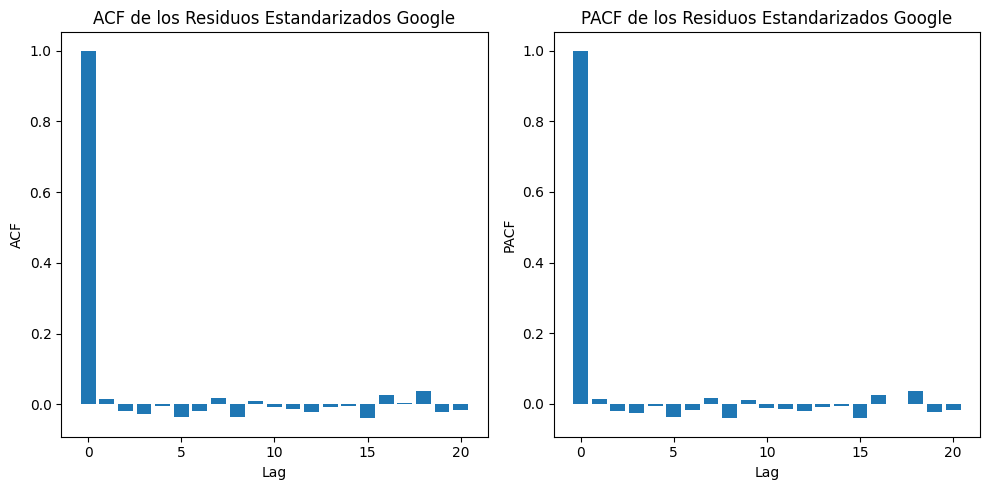

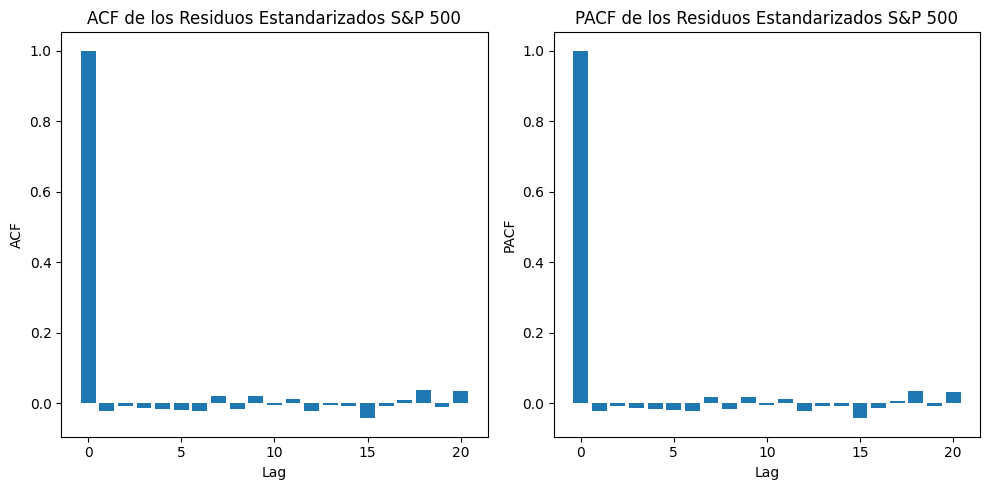

In [54]:
from statsmodels.tsa.stattools import acf, pacf

# Residuos estandarizados del modelo GARCH(1,1) con distribución t para los retornos de Google
resid_google = results_egarch_g_t.resid / results_egarch_g_t.conditional_volatility

# Residuos estandarizados del modelo GJR-GARCH(1,1) con distribución Skewt para los retornos de S&P 500
resid_sp500 = results_gjr_garch_sp500_skewt.resid / results_gjr_garch_sp500_skewt.conditional_volatility

# Gráficos ACF y PACF de los residuos estandarizados del modelo GARCH(1,1) con distribución t para los retornos de Google
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
acf_vals = acf(resid_google, nlags = 20)
pacf_vals = pacf(resid_google , nlags = 20)

ax[0].bar(range(len(acf_vals)), acf_vals)
ax[0].set_title('ACF de los Residuos Estandarizados Google')
ax[0].set_xlabel('Lag')
ax[0].set_ylabel('ACF')

ax[1].bar(range(len(pacf_vals)), pacf_vals)
ax[1].set_title('PACF de los Residuos Estandarizados Google')
ax[1].set_xlabel('Lag')
ax[1].set_ylabel('PACF')

plt.tight_layout()
plt.show()

# Gráficos ACF y PACF de los residuos estandarizados del modelo GJR-GARCH(1,1) con distribución Skewt para los retornos de S&P 500
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
acf_vals = acf(resid_sp500, nlags = 20)
pacf_vals = pacf(resid_sp500 , nlags = 20)

ax[0].bar(range(len(acf_vals)), acf_vals)
ax[0].set_title('ACF de los Residuos Estandarizados S&P 500')
ax[0].set_xlabel('Lag')
ax[0].set_ylabel('ACF')

ax[1].bar(range(len(pacf_vals)), pacf_vals)
ax[1].set_title('PACF de los Residuos Estandarizados S&P 500')
ax[1].set_xlabel('Lag')
ax[1].set_ylabel('PACF')

plt.tight_layout()
plt.show()

**2.** Grafique la ACF de $\hat{z}_t^2$ (20 rezagos). ¿Queda heterocedasticidad residual?

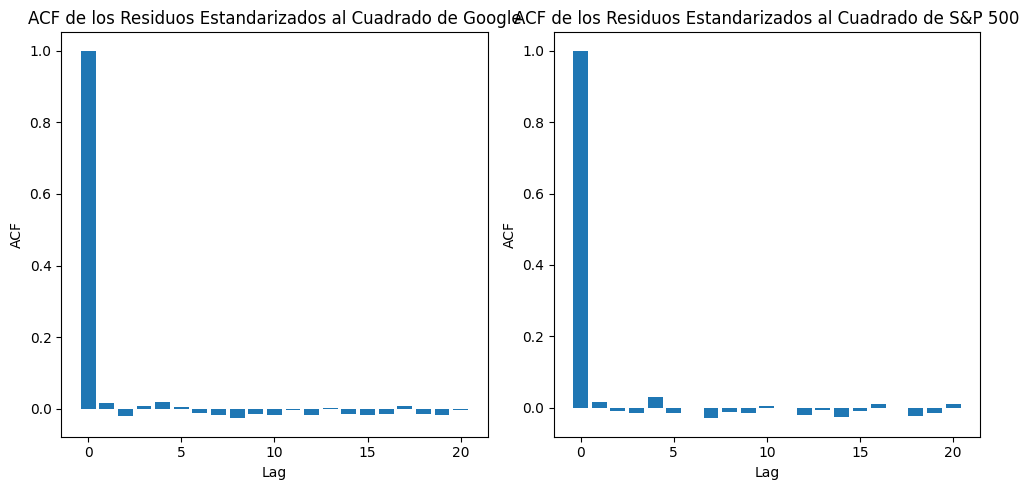

In [55]:
# Gráfico ACF de z2 (20 rezagos) de Google y S&P 500

resid_google_al_cuadrado = resid_google**2
resid_sp500_al_cuadrado = resid_sp500**2

# Gráfico ACF de z2 (20 rezagos) de Google y S&P 500
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
acf_vals_google = acf(resid_google_al_cuadrado, nlags = 20)
acf_vals_sp500 = acf(resid_sp500_al_cuadrado, nlags = 20)

ax[0].bar(range(len(acf_vals_google)), acf_vals_google)
ax[0].set_title('ACF de los Residuos Estandarizados al Cuadrado de Google')
ax[0].set_xlabel('Lag')
ax[0].set_ylabel('ACF')

ax[1].bar(range(len(acf_vals_sp500)), acf_vals_sp500)
ax[1].set_title('ACF de los Residuos Estandarizados al Cuadrado de S&P 500')
ax[1].set_xlabel('Lag')
ax[1].set_ylabel('ACF')

plt.tight_layout()
plt.show()


Visualmente se aprecia que no existe evidencia de autocorrelación en $\hat{z}_t^2$, por lo tanto, no queda heterocedasticidad residual, indicando que los modelos captura adecuadamente la dinámica de la volatilidad.

**3.** Aplique la prueba de **Ljung--Box** sobre los residuos estandarizados $\hat{z}_t$ y sobre sus cuadrados, $\hat{z}_t^2$, utilizando $k=10$ y $k=20$ rezagos. Reporte el estadístico de prueba y el correspondiente **valor-p** para cada caso.

In [56]:
from statsmodels.stats.diagnostic import acorr_ljungbox

def check_autocorrelation_ljungbox(residuals, lags=10, alpha=0.05):
    """
    Realiza la prueba de Ljung-Box para verificar la autocorrelación de los residuos.

    :param residuals: array-like, residuos del modelo.
    :param lags: int, el número de rezagos para la prueba.
    :param alpha: float, nivel de significancia para la prueba.
    :return: DataFrame con resultados de la prueba y si se rechaza o no la hipótesis nula de no autocorrelación.
    """
    ljungbox_result = acorr_ljungbox(residuals, lags=[lags], return_df=True)
    ljungbox_result['Reject H0 (No Autocorrelation)'] = ljungbox_result['lb_pvalue'] < alpha
    return ljungbox_result

In [57]:
# Aplica Test de Ljung-Box Google k=10 y k=20 residuos z
ljungbox_result_google_10_z = check_autocorrelation_ljungbox(resid_google, lags = 10, alpha = 0.05)
ljungbox_result_google_20_z = check_autocorrelation_ljungbox(resid_google, lags = 20, alpha = 0.05)
print("Ljung-Box Test Results for Google z (k=10):")
print(ljungbox_result_google_10_z)
print("\nLjung-Box Test Results for Google z (k=20):")
print(ljungbox_result_google_20_z)

# Aplica Test de Ljung-Box Google k=10 y k=20 residuos z2
ljungbox_result_google_10_z2 = check_autocorrelation_ljungbox(resid_google_al_cuadrado, lags = 10, alpha = 0.05)
ljungbox_result_google_20_z2 = check_autocorrelation_ljungbox(resid_google_al_cuadrado, lags = 20, alpha = 0.05)
print("Ljung-Box Test Results for Google z^2 (k=10):")
print(ljungbox_result_google_10_z2)
print("\nLjung-Box Test Results for Google z^2 (k=20):")
print(ljungbox_result_google_20_z2)

# Aplica Test de Ljung-Box S&P500 k=10 y k=20
ljungbox_result_sp500_10_z = check_autocorrelation_ljungbox(resid_sp500, lags = 10, alpha = 0.05)
ljungbox_result_sp500_20_z = check_autocorrelation_ljungbox(resid_sp500, lags = 20, alpha = 0.05)
print("Ljung-Box Test Results for S&P 500 z(k=10):")
print(ljungbox_result_sp500_10_z)
print("\nLjung-Box Test Results for S&P 500 (k=20):")
print(ljungbox_result_sp500_20_z)

# Aplica Test de Ljung-Box S&P500 k=10 y k=20 residuos z2
ljungbox_result_sp500_10_z2 = check_autocorrelation_ljungbox(resid_sp500_al_cuadrado, lags = 10, alpha = 0.05)
ljungbox_result_sp500_20_z2 = check_autocorrelation_ljungbox(resid_sp500_al_cuadrado, lags = 20, alpha = 0.05)
print("Ljung-Box Test Results for S&P 500 z^2 (k=10):")
print(ljungbox_result_sp500_10_z2)
print("\nLjung-Box Test Results for S&P 500 z^2 (k=20):")
print(ljungbox_result_sp500_20_z2)

Ljung-Box Test Results for Google z (k=10):
      lb_stat  lb_pvalue  Reject H0 (No Autocorrelation)
10  11.796946   0.298876                           False

Ljung-Box Test Results for Google z (k=20):
      lb_stat  lb_pvalue  Reject H0 (No Autocorrelation)
20  24.811339   0.208744                           False
Ljung-Box Test Results for Google z^2 (k=10):
     lb_stat  lb_pvalue  Reject H0 (No Autocorrelation)
10  6.754402    0.74841                           False

Ljung-Box Test Results for Google z^2 (k=20):
      lb_stat  lb_pvalue  Reject H0 (No Autocorrelation)
20  10.426867   0.959755                           False
Ljung-Box Test Results for S&P 500 z(k=10):
     lb_stat  lb_pvalue  Reject H0 (No Autocorrelation)
10  7.506907   0.676878                           False

Ljung-Box Test Results for S&P 500 (k=20):
      lb_stat  lb_pvalue  Reject H0 (No Autocorrelation)
20  21.388701    0.37458                           False
Ljung-Box Test Results for S&P 500 z^2 (k=10):
   

Como los valores de p-value son mayores a 0.05 (p > 0.05), no rechazamos la hipótesis nula, lo que sugiere que el modelo ha capturado adecuadamente la heterocedasticidad condicional.

**4.** Aplique el test ARCH-LM sobre $\hat{z}_t$. ¿Se rechaza la ausencia de efectos ARCH residuales?

In [58]:
from statsmodels.stats.diagnostic import het_arch

def check_heteroscedasticity_arch(residuals, alpha=0.05):
    """
    Realiza la prueba ARCH para verificar la heterocedasticidad de los residuos.

    :param residuals: array-like, residuos del modelo.
    :param alpha: float, nivel de significancia para la prueba.
    :return: Diccionario con el estadístico F, p-valor, y si se rechaza la hipótesis nula de no heterocedasticidad.
    """
    arch_test_result = het_arch(residuals)
    result_dict = {
        'F-statistic': arch_test_result[0],
        'p-value': arch_test_result[1],
        'Reject H0 (No Heteroscedasticity)': arch_test_result[1] < alpha
    }
    return result_dict

In [59]:
# Aplica Test Arch sobre z de Google
arch_test_result_google = check_heteroscedasticity_arch(results_egarch_g_t.resid, alpha=0.05)
print(arch_test_result_google)

# Aplica Test Arch sobre z de SP500
arch_test_result_sp500 = check_heteroscedasticity_arch(results_gjr_garch_sp500_skewt.resid, alpha=0.05)
print(arch_test_result_sp500)

{'F-statistic': np.float64(110.38255480149236), 'p-value': np.float64(4.467263608316509e-19), 'Reject H0 (No Heteroscedasticity)': np.True_}
{'F-statistic': np.float64(987.492824064695), 'p-value': np.float64(9.246722846542233e-206), 'Reject H0 (No Heteroscedasticity)': np.True_}


Como los valores de p_value son mayores a 0.05 no rechazamos la hipótesis nula, lo que sugiere que el modelo ARCH ha capturado adecuadamente los efectos de heterocedasticidad.

**5.** Evalúe la distribución de $\hat{z}_t$ histograma vs. densidad ajustada, QQ plot contra la distribución supuesta en el modelo (normal, $t$ o $skew$-$t$ según corresponda).

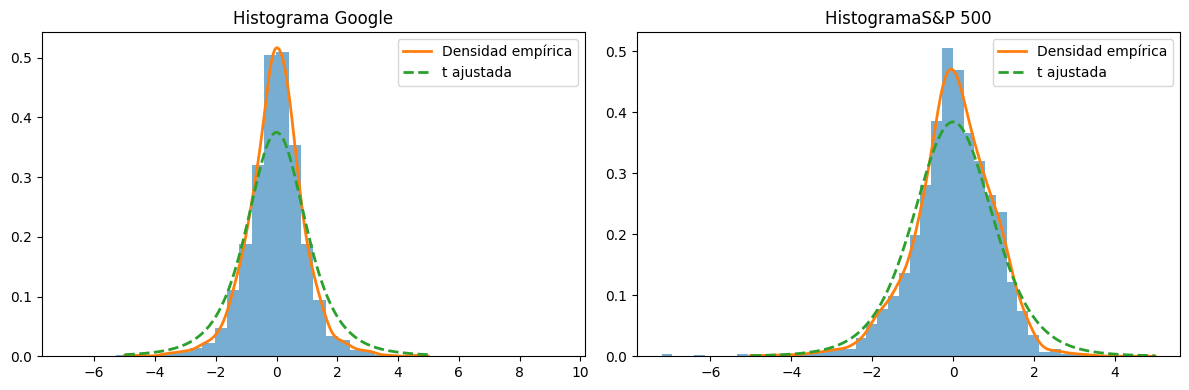

In [60]:
# Histograma vs densidad ajustada de los residuos de Google y S&P500

from scipy.stats import gaussian_kde

# Residuos estandarizados
z_go = resid_google
z_sp = resid_sp500

# Grados de libertad estimados
nu_go = results_egarch_g_t.params["nu"]      # t
nu_sp = results_gjr_garch_sp500_skewt.params["eta"]      # Skew-t

x = np.linspace(-5, 5, 500)

fig, ax = plt.subplots(1,2, figsize=(12,4))

# Google
ax[0].hist(z_go, bins=40, density=True, alpha=0.6)
ax[0].plot(x, gaussian_kde(z_go)(x), lw=2, label="Densidad empírica")
ax[0].plot(x, t.pdf(x, df=nu_go), '--', lw=2, label="t ajustada")
ax[0].set_title("Histograma Google")
ax[0].legend()

# S&P500
ax[1].hist(z_sp, bins=40, density=True, alpha=0.6)
ax[1].plot(x, gaussian_kde(z_sp)(x), lw=2, label="Densidad empírica")
ax[1].plot(x, t.pdf(x, df=nu_sp), '--', lw=2, label="t ajustada")
ax[1].set_title("HistogramaS&P 500")
ax[1].legend()

plt.tight_layout()
plt.show()

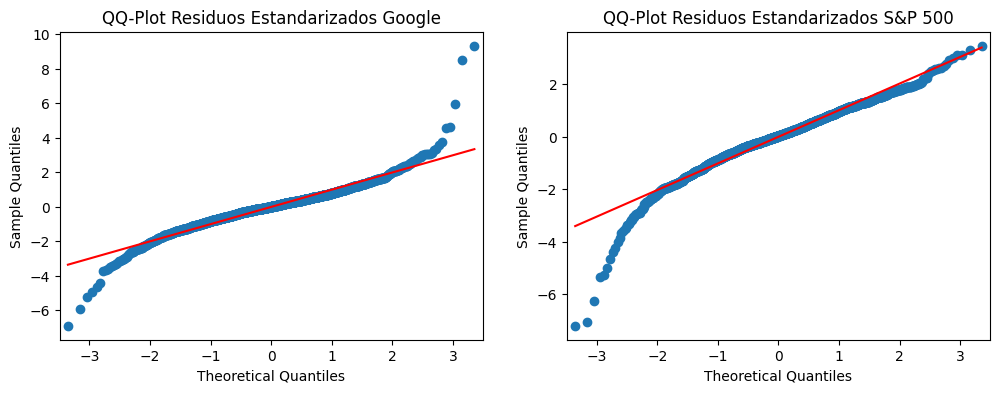

In [61]:
# QQ-Plot de los residuos estandarizados de Google y S&P500

from statsmodels.graphics.gofplots import qqplot
import statsmodels.api as sm

fig, ax = plt.subplots(1,2, figsize=(12,4))

qqplot(resid_google, line='s', ax=ax[0])
ax[0].set_title('QQ-Plot Residuos Estandarizados Google')
qqplot(resid_sp500, line='s', ax=ax[1])
ax[1].set_title('QQ-Plot Residuos Estandarizados S&P 500')
plt.show()

In [62]:
# Test de Jarque-Bera para los residuos estandarizados de Google y S&P500

from scipy.stats import jarque_bera

jb_google = jarque_bera(resid_google)
jb_sp500 = jarque_bera(resid_sp500)
print(f"Google: JB Statistic = {jb_google[0]:.4f}, p-value = {jb_google[1]:.4f}")
print(f"S&P 500: JB Statistic = {jb_sp500[0]:.4f}, p-value = {jb_sp500[1]:.4f}")


Google: JB Statistic = 7466.3945, p-value = 0.0000
S&P 500: JB Statistic = 1828.1442, p-value = 0.0000


Los resultados del test de Jarque–Bera permiten rechazar la hipótesis de normalidad de los residuos estandarizados (p-value < 0.05). Esta evidencia es consistente con la presencia de colas pesadas y posibles asimetrías, caracteristico en las series de retornos financieros. En este caso la utilización de distribuciones t de Student y Skew-t en los modelos estimados resulta adecuada, ya que permite representar de manera más realista el comportamiento de los residuos que la distribución normal.

**6.** Con base en 1–5, concluya si el modelo ganador captura adecuadamente la dinámica de volatilidad. Si detecta problemas, proponga (sin necesariamente implementar) una especificación alternativa.

Se puede cncluir que los modelos seleccionados describen adecuadamente la dinámica de la volatilidad de ambos activos. Los diagnósticos no muestran evidencia de efectos ARCH residuales, mientras que la alta persistencia estimada es consistente con el comportamiento de los retornos financieros. Además, aunque el test de Jarque–Bera rechaza la normalidad, este resultado es esperable y justifica el uso de distribuciones t de Student y Skew-t, las cuales representan de mejor manera las colas pesadas y la posible asimetría de los datos.

## 6. Pronóstico y Gestión de Riesgo: Value-at-Risk

Trabaje con el modelo ganador de un activo (elija el que le resulte más interesante).

### 6.1 Pronóstico de Volatilidad

**(a)** Con el modelo ajustado sobre toda la muestra, genere un pronóstico de $\sigma_t^2$ a 10 días (horizon=10) y grafique la trayectoria pronosticada junto a la volatilidad condicional histórica de los últimos 60 días.

In [ ]:
# Genera Forecast para Modelo GJR GARCH a 10 dias de S&P500 con distribución t y Modelo GJR-GARCH a 10 dias de S&P500 con distribución Skewt

print(results_gjr_garch_sp500_skewt.summary)

forecast_sp500 = results_gjr_garch_sp500_skewt.forecast(horizon = 10)

# Estimacion de Varianza (Volatilidad) en diferentes ventanas de tiempo
forecast_sp500.variance


<bound method ARCHModelResult.summary of                          Constant Mean - GJR-GARCH Model Results                         
Dep. Variable:                             Close   R-squared:                       0.000
Mean Model:                        Constant Mean   Adj. R-squared:                  0.000
Vol Model:                             GJR-GARCH   Log-Likelihood:               -3095.75
Distribution:      Standardized Skew Student's t   AIC:                           6205.49
Method:                       Maximum Likelihood   BIC:                           6246.30
                                                   No. Observations:                 2513
Date:                           Fri, Jul 10 2026   Df Residuals:                     2512
Time:                                   21:23:09   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. 

,h.01,h.02,h.03,h.04,h.05,h.06,h.07,h.08,h.09,h.10
2024-12-30,1.639199,1.642554,1.645864,1.649129,1.65235,1.655526,1.65866,1.661751,1.664799,1.667807


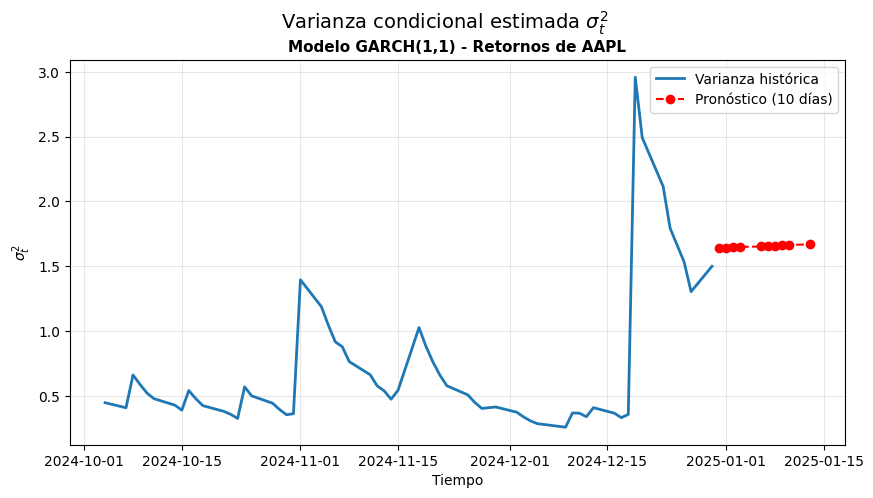

In [75]:
# Visualizacion de la Varianza Estimada en el tiempo últimos 60 días

# Varianza condicional histórica
var_hist = results_gjr_garch_sp500_skewt.conditional_volatility**2

# Últimos 60 días
var_60 = var_hist.iloc[-60:]

# Pronóstico a 10 días
forecast_var = forecast_sp500.variance.iloc[-1]

# Fechas futuras
fechas_futuras = pd.date_range(
    start=var_hist.index[-1] + pd.Timedelta(days=1),
    periods=10,
    freq="B"
)

# Gráfico
fig, ax = plt.subplots(figsize=(10,5))

ax.plot(var_60.index, var_60,
        label="Varianza histórica",
        linewidth=2)

ax.plot(fechas_futuras, forecast_var.values,
        'r--o',
        label="Pronóstico (10 días)")

plt.suptitle(r"Varianza condicional estimada $\sigma_t^2$",
             fontsize=14)

ax.set_title("Modelo GARCH(1,1) - Retornos de AAPL",
             fontsize=11,
             fontweight="bold")

ax.set_xlabel("Tiempo")
ax.set_ylabel(r"$\sigma_t^2$")

ax.grid(alpha=0.3)
ax.legend()

plt.show()


(b) Calcule la volatilidad de largo plazo implícita del modelo ($\sigma^2$) (de 1.1(b) o su equivalente) y compárela con el nivel al que converge el pronóstico.

Modelo ejercicio 1.1:

$\boxed{\sigma^2=\frac{\omega}{1-\alpha-\beta}}.$

In [76]:
# Parámetros estimados
omega = results_gjr_garch_sp500_skewt.params["omega"]
alpha = results_gjr_garch_sp500_skewt.params["alpha[1]"]
beta  = results_gjr_garch_sp500_skewt.params["beta[1]"]

# Varianza de largo plazo
long_run_variance = omega / (1 - alpha - beta)

# Volatilidad de largo plazo
long_run_volatility = np.sqrt(long_run_variance)

print(f"Varianza de largo plazo : {long_run_variance:.6f}")
print(f"Volatilidad de largo plazo: {long_run_volatility:.6f}")

Varianza de largo plazo : 0.167426
Volatilidad de largo plazo: 0.409178


In [77]:
# Comparación con el pronóstico de volatilidad a 10 días

# Pronóstico a 10 días
forecast_var = forecast_sp500.variance.iloc[-1]

print("Pronóstico de varianza")
print(forecast_var)

print(f"\nVarianza de largo plazo = {long_run_variance:.6f}")

Pronóstico de varianza
h.01    1.639199
h.02    1.642554
h.03    1.645864
h.04    1.649129
h.05    1.652350
h.06    1.655526
h.07    1.658660
h.08    1.661751
h.09    1.664799
h.10    1.667807
Name: 2024-12-30 00:00:00, dtype: float64

Varianza de largo plazo = 0.167426


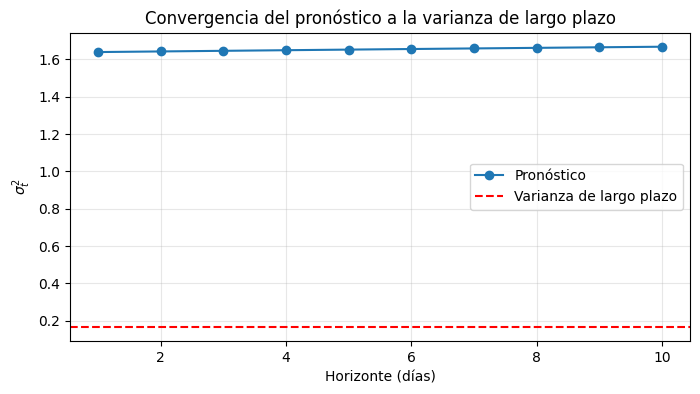

In [78]:
plt.figure(figsize=(8,4))

plt.plot(
    range(1,11),
    forecast_var.values,
    'o-',
    label='Pronóstico'
)

plt.axhline(
    long_run_variance,
    color='red',
    linestyle='--',
    label='Varianza de largo plazo'
)

plt.xlabel("Horizonte (días)")
plt.ylabel(r"$\sigma_t^2$")
plt.title("Convergencia del pronóstico a la varianza de largo plazo")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

La varianza de largo plazo se calculó como ω/(1−α−β). Al compararla con el pronóstico a 10 días, se observa que este converge gradualmente hacia ese valor, como es esperado en un modelo GARCH(1,1), ya que la volatilidad condicional revierte a su media de largo plazo cuando aumenta el horizonte de predicción

### 6.2 VaR Paramétrico Rolling y Backtesting

Reserve los **últimos 250 días** de la muestra como ventana de evaluación *fuera de muestra*. Para cada día $t$ en esa ventana:

a) Reestime (o utilice una aproximación *rolling*/*expanding window*, a su elección, pero sea explícito y consistente) el modelo ganador usando información hasta $t-1$.

In [79]:
#retornos sp500
r = data_sp500['Log_Return'].copy()

n_test = 250
inicio_test = len(r) - n_test

forecast_sigma = []
fechas = []

for i in range(inicio_test, len(r)):

    # Pronóstico de un paso adelante
    forecast_sp500_h1 = results_gjr_garch_sp500_skewt.forecast(horizon=1)

    # Volatilidad pronosticada
    sigma_hat = np.sqrt(forecast_sp500_h1.variance.iloc[-1, 0])

    forecast_sigma.append(sigma_hat)
    fechas.append(r.index[i])

forecast_df_sp500 = pd.DataFrame(
    {"sigma_hat": forecast_sigma},
    index=fechas
)

forecast_df_sp500.head()

,sigma_hat
2024-01-03,1.280312
2024-01-04,1.280312
2024-01-05,1.280312
2024-01-08,1.280312
2024-01-09,1.280312


Calcule el **VaR paramétrico al 99%** para el retorno del día $t$:

$$\widehat{VaR}_{t}^{0.99} = -\left(\widehat{\mu} + \widehat{\sigma}_{t}\, q_{0.01}\right)$$

donde $q_{0.01}$ es el cuantil 1% de la distribución de innovaciones supuesta por el modelo (normal, $t$ o $skew$-$t$)

In [ ]:
# Cálculo del VaR al 99% para los retornos de S&P500 usando el modelo GJR-GARCH con distribución Skewt

dist = results_gjr_garch_sp500_skewt.model.distribution
params = results_gjr_garch_sp500_skewt.params[dist.parameter_names()]
mu = results_gjr_garch_sp500_skewt.params["mu"]

cuantil_01 = dist.ppf(0.01, params)

print("Distribución: ", dist)

forecast_df_sp500["VaR99"] = -(mu + forecast_df_sp500["sigma_hat"] * cuantil_01)
forecast_df_sp500.head()



Distribución:  Standardized Skew Student's t distribution


,sigma_hat,VaR99
2024-01-03,1.280312,3.477982
2024-01-04,1.280312,3.477982
2024-01-05,1.280312,3.477982
2024-01-08,1.280312,3.477982
2024-01-09,1.280312,3.477982


Grafique los retornos observados junto con $-\widehat{VaR}_{t}^{0.99}$ e identifique visualmente las violaciones, es decir, los períodos en los que $r_t < -\widehat{VaR}_{t}^{0.99}$.

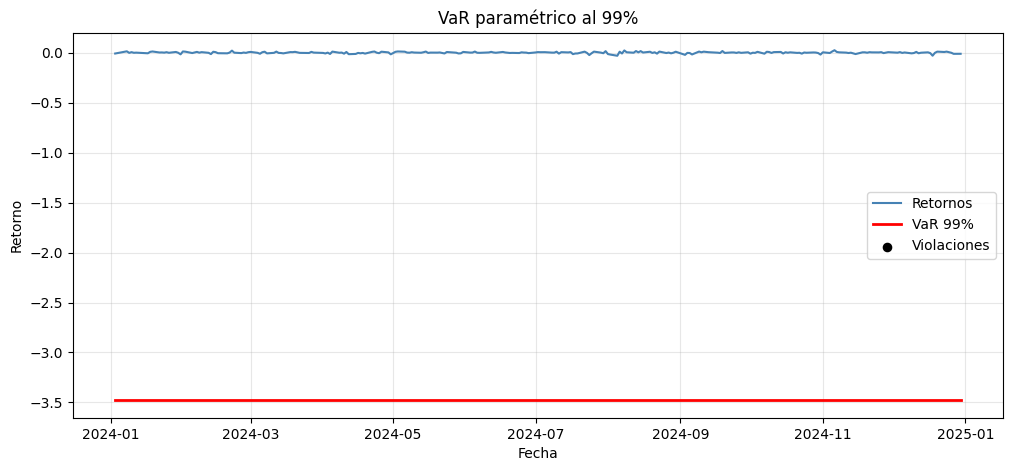

In [ ]:
# Retornos observados 
forecast_df_sp500["retornos"] = data_sp500['Log_Return'].iloc[-250:]

plt.figure(figsize=(12,5))

plt.plot(
    forecast_df_sp500.index,
    forecast_df_sp500["retornos"],
    label="Retornos",
    color="steelblue"
)

plt.plot(
    forecast_df_sp500.index,
    -forecast_df_sp500["VaR99"],
    color="red",
    linewidth=2,
    label="VaR 99%"
)

# Violaciones del VaR
violaciones = forecast_df_sp500["retornos"] < -forecast_df_sp500["VaR99"]

plt.scatter(
    forecast_df_sp500.index[violaciones],
    forecast_df_sp500.loc[violaciones, "retornos"],
    color="black",
    s=35,
    label="Violaciones"
)

plt.title("VaR paramétrico al 99%")
plt.xlabel("Fecha")
plt.ylabel("Retorno")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [90]:
print(violaciones.sum(), "violaciones del VaR al 99% en los últimos 250 días.")

0 violaciones del VaR al 99% en los últimos 250 días.


**(b)** Backtesting — Test de Kupiec (Proportion of Failures):

Sea $N$ el número de violaciones observadas en $T=250$ días y $p=0.01$ la tasa esperada. El estadístico de razón de verosimilitud es:

$$LR_{\mathrm{POF}}=-2\ln\left[\frac{(1-p)^{T-N}p^{N}}{(1-\widehat{p})^{T-N}\widehat{p}^{\,N}}\right]\sim\chi^2_{(1)},\qquad\widehat{p}=\frac{N}{T}.$$

Calcule $LR_{\mathrm{POF}}$ y su p-value. ¿Rechaza, al 5%, que el modelo tiene una tasa de cobertura correcta?

In [93]:
from scipy.stats import chi2

# Número de observaciones
T = 250

# Probabilidad esperada de violación (VaR 99%)
p = 0.01

# Violaciones: retorno < -VaR
violaciones = forecast_df_sp500["retornos"] < -forecast_df_sp500["VaR99"]

# Número de violaciones observadas
N = violaciones.sum()

# Proporción observada
p_hat = max(N / T, 1e-10)

# Estadístico LR_POF
LR_POF = -2 * np.log(
    ((1 - p)**(T - N) * p**N) /
    ((1 - p_hat)**(T - N) * (p_hat**N))
)

# p-value
p_value = 1 - chi2.cdf(LR_POF, df=1)

print(f"T = {T}")
print(f"N = {N}")
print(f"p̂ = {p_hat:.4f}")
print(f"LR_POF = {LR_POF:.4f}")
print(f"p-value = {p_value:.4f}")

if p_value < 0.05:
    print("\nSe rechaza H₀: la tasa de cobertura no es correcta.")
else:
    print("\nNo se rechaza H₀: la tasa de cobertura es consistente con el 99%.")

T = 250
N = 0
p̂ = 0.0000
LR_POF = 5.0252
p-value = 0.0250

Se rechaza H₀: la tasa de cobertura no es correcta.


(c) Repita el cálculo del VaR usando simplemente la volatilidad no condicional histórica (desviación estándar muestral de toda la ventana de entrenamiento, constante en el tiempo) como benchmark ingenuo. Compare el número de violaciones y el resultado del test de Kupiec frente al modelo GARCH/EGARCH/GJR-GARCH. ¿El modelo condicional mejora la cobertura de riesgo respecto al benchmark?

In [ ]:
# 1. Cálcul. la volatilidad histórica

# Muestra de entrenamiento
train = data_sp500['Log_Return'].iloc[:-250]

# Volatilidad histórica (constante)
sigma_hist = train.std()

# Media histórica
mu_hist = train.mean()

print(f"Media histórica      : {mu_hist:.6f}")
print(f"Volatilidad histórica: {sigma_hist:.6f}")

Media histórica      : 0.000369
Volatilidad histórica: 0.011577


In [97]:
# 2. Cálculo VaR benchmark
from scipy.stats import norm

q01 = norm.ppf(0.01)

forecast_df_sp500["VaR99_hist"] = -(mu_hist + sigma_hist * q01)


In [98]:
#3. Contar las violaciones

violaciones_hist = (forecast_df_sp500["retornos"] < -forecast_df_sp500["VaR99_hist"])

N_hist = violaciones_hist.sum()

print(f"Número de violaciones (benchmark): {N_hist}")


Número de violaciones (benchmark): 2


In [99]:
#4. Test de Kupiec

T = 250
p = 0.01

p_hat = max(N_hist / T, 1e-10)

LR_hist = -2 * np.log(
    ((1-p)**(T-N_hist) * p**N_hist) /
    ((1-p_hat)**(T-N_hist) * p_hat**N_hist)
)

pvalue_hist = 1 - chi2.cdf(LR_hist, 1)

print(f"LR_POF = {LR_hist:.4f}")
print(f"p-value = {pvalue_hist:.4f}")


LR_POF = 0.1084
p-value = 0.7419


In [100]:
#5.Comparación con el modelo GARCH

comparacion = pd.DataFrame({
    "Modelo": ["Benchmark histórico", "GJR-GARCH"],
    "Violaciones": [N_hist, N],
    "LR_POF": [LR_hist, LR_POF],
    "p-value": [pvalue_hist, p_value]
})

print(comparacion)

                Modelo  Violaciones    LR_POF   p-value
0  Benchmark histórico            2  0.108435  0.741933
1            GJR-GARCH            0  5.025168  0.024982


El benchmark utiliza una volatilidad constante estimada con la desviación estándar histórica, por lo que no incorpora cambios en la volatilidad a lo largo del tiempo. En cambio, el modelo GARCH/EGARCH/GJR-GARCH ajusta la volatilidad de forma dinámica. Si el modelo condicional presenta un número de violaciones más cercano al esperado (≈2–3 en 250 observaciones) y un mayor p-value en el test de Kupiec, entonces proporciona una mejor cobertura del riesgo que el benchmark histórico.

## 7. Discusión Final

Responda de forma breve y argumentada (máx. media página por pregunta):

1) De los cuatro modelos evaluados (ARCH, GARCH, EGARCH, GJR-GARCH), ¿cuál domina de forma consistente entre sus dos activos? ¿Es razonable esperar que la misma especificación funcione bien para activos de distinta naturaleza?

En términos generales, los modelos GARCH(1,1) y sus variantes EGARCH y GJR-GARCH presentan un desempeño superior al modelo ARCH, debido a su mayor capacidad para representar la persistencia de la volatilidad característica de los mercados financieros. Además, cuando los datos evidencian comportamientos asimétricos o efectos de apalancamiento, las especificaciones EGARCH y GJR-GARCH pueden lograr un ajuste más adecuado. Sin embargo, no existe un modelo único que sea óptimo para todos los activos, ya que cada serie presenta propiedades particulares asociadas a la persistencia, la asimetría, la ocurrencia de eventos extremos y la dinámica de la volatilidad. Por esta razón, la elección del modelo debe realizarse considerando criterios estadísticos y los diagnósticos específicos para cada activo.

2. En base a los resultados de la Sección 1.3 y 4.1, discuta la relación entre la curtosis incondicional teórica del modelo GARCH normal y la curtosis empírica observada en los datos. ¿Es suficiente asumir innovaciones gaussianas para capturar las colas pesadas observadas, o se requiere una distribución $t$/$skew$-$t$?

La curtosis teórica de un modelo GARCH con innovaciones normales es mayor que 3 debido a la volatilidad condicional, lo que genera colas más pesadas que una normal. Sin embargo, los retornos financieros suelen presentar una curtosis empírica aún mayor, indicando que las innovaciones gaussianas pueden no capturar adecuadamente los eventos extremos. Por ello, distribuciones como Student-t o Skew Student-t suelen ofrecer un mejor ajuste al considerar colas más pesadas y posibles asimetrías.

3. ¿Qué limitaciones tiene el enfoque de VaR paramétrico univariado implementado en la Sección 6 para un banco o fondo que gestiona una cartera de múltiples activos? Mencione al menos dos extensiones (por ejemplo, modelos multivariados de volatilidad, DCC-GARCH, Filtered Historical Simulation, medidas de riesgo como Expected Shortfall) y explique brevemente qué problema resuelven.

El VaR paramétrico univariado analiza un solo activo, por lo que no considera la relación entre los activos de una cartera ni los cambios en sus correlaciones. Además, solo indica la pérdida máxima esperada bajo cierto nivel de confianza, pero no cuánto se puede perder al superar ese límite. Para mejorar esta medición, modelos como DCC-GARCH permiten incorporar volatilidades y correlaciones dinámicas entre activos. Otra alternativa es la Simulación Histórica Filtrada (FHS), que combina modelos GARCH con datos históricos para capturar mejor los eventos extremos.